# Imports

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# import scipy
import seaborn as sns
# import statistics
import warnings
# from scipy.stats import binomtest, ks_2samp
# from BorutaShap import BorutaShap
from pathlib import Path
from pygam import LinearGAM, s, f
from pygam.terms import Intercept, TermList
# from scipy import stats
from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV, ElasticNetCV, ElasticNet, Lasso, ARDRegression, RidgeCV, LinearRegression
from sklearn.linear_model._coordinate_descent import LinearModelCV
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold, cross_val_score, cross_validate, GridSearchCV, LeaveOneOut, LeaveOneGroupOut, LearningCurveDisplay, learning_curve, StratifiedKFold, StratifiedGroupKFold, GroupKFold
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder, SplineTransformer, MinMaxScaler, FunctionTransformer, OneHotEncoder, OrdinalEncoder, RobustScaler
from sklearn.utils import check_array, check_X_y
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
import itertools
from typing import Union
import matplotlib.cm as cm
import matplotlib as mpl
from sklearn.inspection import permutation_importance

import os
import sys
sys.path.append(os.path.abspath(".."))
from utils import distribution_plot, draw_heat_pair_plot

warnings.filterwarnings("ignore")

HERE = Path.cwd().resolve().parent
DATASETS = HERE.parent/'datasets'
# from google.colab import drive
# %load_ext google.colab.data_table

In [2]:
from matplotlib import rcParams
sns.set_theme(style="ticks")
# Set global font sizes
rcParams.update({
    'axes.titlesize': 18,       # Title font size
    'axes.labelsize': 17,       # X and Y label font size
    'xtick.labelsize': 15,      # X tick label font size
    'ytick.labelsize': 15,      # Y tick label font size
    'legend.fontsize': 14,      # Legend font size
    'font.size': 17             # Default font size
})


# Load data

In [3]:
data_folder = DATASETS/ "processed"
dataset: pd.DataFrame = pd.read_csv(data_folder/'substrate_hierarchically_averaged_clean_data_residual_included.csv')
dataset.shape

(91, 114)

**Quick glance at the data**

In [5]:
dataset.head(3)

,substrate ID,location,carbon number,electrode,scan V direction,mean |J| @ -0.5 V,mean ln(|J|) @ -0.5 V,mean log(|J|) @ -0.5 V,median |J| @ -0.5 V,median ln(|J|) @ -0.5 V,...,log_water content,SEM ln(|J|) @ |0.5| V,log water content,relative std ln(|J|) @ |0.5| V (%),predicted ln(|J|) @ |0.5| V,residual ln(|J|) @ |0.5| V,predicted ln(|J|) @ |0.5| V (low-group),predicted ln(|J|) @ |0.5| V (high-group),residual ln(|J|) @ |0.5| V (low-group),residual ln(|J|) @ |0.5| V (high-group)
0,01302012,"Boston, Massachusetts",13,Au,1.0,0.000259,-8.862936,-3.849124,0.000124,-9.035416,...,-2.739555,0.307046,-2.739555,10.703204,-5.206251,-3.865470,-5.276606,-5.444545,-3.795115,-3.627176
1,04042016,"Ames, Iowa",16,Au,1.0,0.000736,-7.296816,-3.168967,0.000709,-7.316749,...,-2.521997,0.145170,-2.521997,3.836633,-7.676141,0.108554,-7.545329,-7.513071,-0.022258,-0.054516
2,04052016,"Ames, Iowa",12,Au,1.0,0.088237,-2.571779,-1.116909,0.086495,-2.449967,...,-2.442403,0.254365,-2.442403,20.731866,-4.382955,1.639458,-4.520366,-4.513412,1.776869,1.769916


In [6]:
dataset.columns

Index(['substrate ID', 'location', 'carbon number', 'electrode',
       'scan V direction', 'mean |J| @ -0.5 V', 'mean ln(|J|) @ -0.5 V',
       'mean log(|J|) @ -0.5 V', 'median |J| @ -0.5 V',
       'median ln(|J|) @ -0.5 V',
       ...
       'log_water content', 'SEM ln(|J|) @ |0.5| V', 'log water content',
       'relative std ln(|J|) @ |0.5| V (%)', 'predicted ln(|J|) @ |0.5| V',
       'residual ln(|J|) @ |0.5| V', 'predicted ln(|J|) @ |0.5| V (low-group)',
       'predicted ln(|J|) @ |0.5| V (high-group)',
       'residual ln(|J|) @ |0.5| V (low-group)',
       'residual ln(|J|) @ |0.5| V (high-group)'],
      dtype='object', length=114)

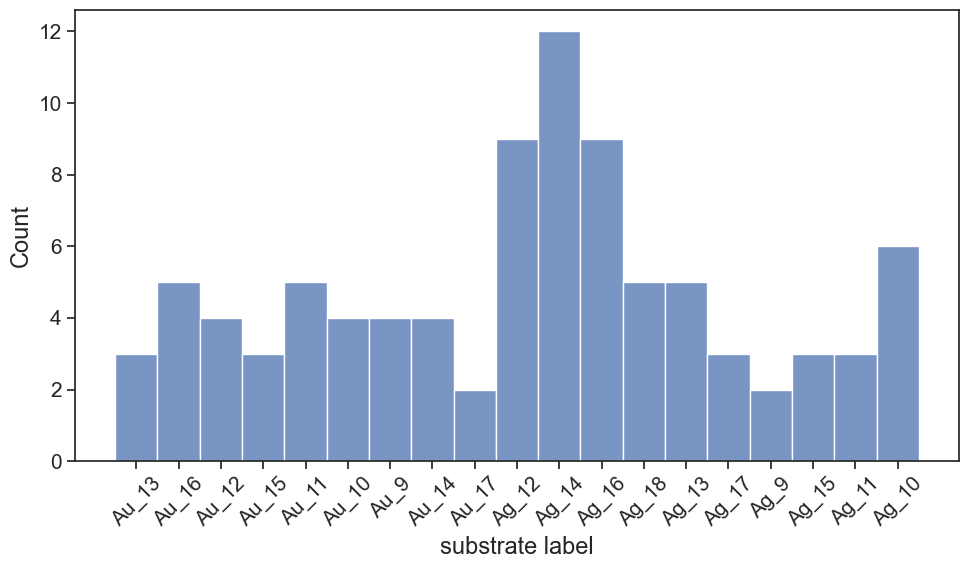

In [7]:
dataset["substrate label"] = dataset['electrode'] + "_" + dataset['carbon number'].astype(str)
plt.figure(figsize=(10, 6))
ax = sns.histplot(data=dataset, x="substrate label")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
plt.tight_layout()
plt.show()

<Axes: xlabel='carbon number', ylabel='var ln(|J|) @ |0.5| V'>

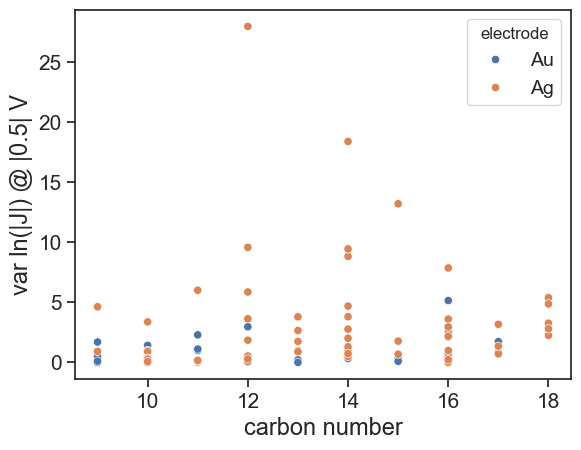

In [8]:
sns.scatterplot(dataset, x="carbon number", y="var ln(|J|) @ |0.5| V", hue="electrode")

<Axes: xlabel='mean ln(|J|) @ |0.5| V', ylabel='var ln(|J|) @ |0.5| V'>

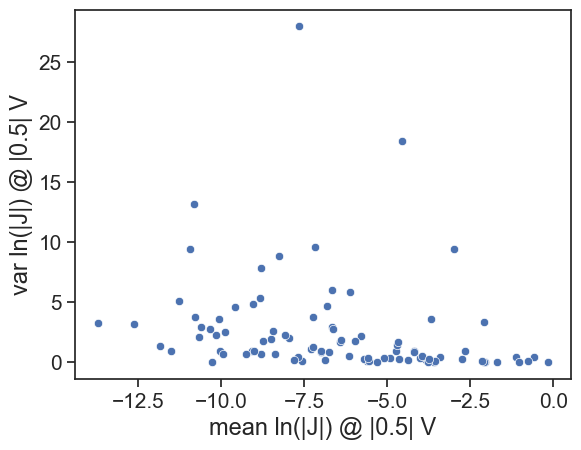

In [9]:
sns.scatterplot(dataset, x="mean ln(|J|) @ |0.5| V", y="var ln(|J|) @ |0.5| V")

# Feature encoding & engineering

Encode categorical featuresu using LabelEncoder

In [10]:
dataset["location_MA"] = dataset["location"].apply(lambda x: 1 if x == "Boston, Massachusetts" else 0)
dataset["location_IA"] = dataset["location"].apply(lambda x: 1 if x == "Ames, Iowa" else 0)

dataset["electrode_Au"] = dataset["electrode"].apply(lambda x: 1 if x == "Au" else 0)
dataset["electrode_Ag"] = dataset["electrode"].apply(lambda x: 1 if x == "Ag" else 0)

In [11]:
categorical_features = ["location", "electrode"]

for feature in categorical_features:
  dataset[f"{feature}_encoded"] = LabelEncoder().fit_transform(dataset[feature])

Scale periodic features

In [12]:
dataset["time_scaled"] = dataset["time of day"] / 24
dataset["week_day_scaled"] = dataset["day of week"] / 7

In [13]:
print("Columns in the dataset:\n", dataset.columns.to_list())

Columns in the dataset:
 ['substrate ID', 'location', 'carbon number', 'electrode', 'scan V direction', 'mean |J| @ -0.5 V', 'mean ln(|J|) @ -0.5 V', 'mean log(|J|) @ -0.5 V', 'median |J| @ -0.5 V', 'median ln(|J|) @ -0.5 V', 'median log(|J|) @ -0.5 V', 'std |J| @ -0.5 V', 'std ln(|J|) @ -0.5 V', 'std log(|J|) @ -0.5 V', 'var |J| @ -0.5 V', 'var ln(|J|) @ -0.5 V', 'var log(|J|) @ -0.5 V', 'skew |J| @ -0.5 V', 'skew ln(|J|) @ -0.5 V', 'skew log(|J|) @ -0.5 V', 'kurtosis |J| @ -0.5 V', 'kurtosis ln(|J|) @ -0.5 V', 'kurtosis log(|J|) @ -0.5 V', 'K-S test |J| @ -0.5 V', 'K-S test ln(|J|) @ -0.5 V', 'K-S test log(|J|) @ -0.5 V', 'S-W test |J| @ -0.5 V', 'S-W test ln(|J|) @ -0.5 V', 'S-W test log(|J|) @ -0.5 V', 'mean |J| @ +0.5 V', 'mean ln(|J|) @ +0.5 V', 'mean log(|J|) @ +0.5 V', 'median |J| @ +0.5 V', 'median ln(|J|) @ +0.5 V', 'median log(|J|) @ +0.5 V', 'std |J| @ +0.5 V', 'std ln(|J|) @ +0.5 V', 'std log(|J|) @ +0.5 V', 'var |J| @ +0.5 V', 'var ln(|J|) @ +0.5 V', 'var log(|J|) @ +0.5 

# Modeling

In [14]:
labels = dataset["substrate label"]

y = dataset["residual ln(|J|) @ |0.5| V"]
y_high_carb = dataset[ 'residual ln(|J|) @ |0.5| V (high-group)']
y_low_carb = dataset[ 'residual ln(|J|) @ |0.5| V (low-group)']

# y_weights = 1 / dataset["var ln(|J|) @ |0.5| V"]
y_weights = 1 / (dataset["SEM ln(|J|) @ |0.5| V"]**2)


y_phys = dataset["predicted ln(|J|) @ |0.5| V"]
y_phys_low_carb = dataset['predicted ln(|J|) @ |0.5| V (low-group)']
y_phys_high_carb = dataset["predicted ln(|J|) @ |0.5| V (high-group)"]

y_true = dataset["mean ln(|J|) @ |0.5| V"]
y_std = dataset["std ln(|J|) @ |0.5| V"]
y_sem = dataset["SEM ln(|J|) @ |0.5| V"]

X_periodic = dataset[[
    "location",
    "electrode",
    # "carbon number",
    "temperature",
    "log_water content",
    "hr_in_day_cos",
    "hr_in_day_sin",
    "day_in_week_cos",
    "day_in_week_sin",
    # "day of year"
]]

## Pre-processing

In [15]:
def scale_time(feature, period=None):
  return feature / period

def inverse_scale_time(feature, period=None):
  return feature * period

time_period = {"period": 24}
week_period = {"period": 7}
year_period = {"period": 365}
time_scaler = FunctionTransformer(scale_time, inverse_scale_time, check_inverse=True, kw_args=time_period, inv_kw_args=time_period,
                                  feature_names_out="one-to-one")
week_scaler = FunctionTransformer(scale_time, inverse_scale_time, check_inverse=True, kw_args=week_period, inv_kw_args=week_period,
                                  feature_names_out="one-to-one")
year_scaler = FunctionTransformer(scale_time, inverse_scale_time, check_inverse=True, kw_args=year_period, inv_kw_args=year_period,
                                  feature_names_out="one-to-one")

## Modeling tools

In [16]:
# from sklearn.inspection._permutation_importance import _calculate_permutation_scores
# Code is based on scikit-learns permutation importance.

from sklearn.inspection._permutation_importance import check_random_state, _weights_scorer


def _calculate_permutation_scores(estimator, X, y, sample_weight, col_idx,
                                  random_state, n_repeats, scorer):
    """Calculate score when `col_idx` is permuted."""
    random_state = check_random_state(random_state)

    # Copy to ensure thread safety
    X_permuted = X.copy()
    scores = np.zeros(n_repeats)
    shuffling_idx = np.arange(X.shape[0])

    for n_round in range(n_repeats):
        random_state.shuffle(shuffling_idx)

        if hasattr(X_permuted, "iloc"):  # DataFrame
            # Handle col_idx as list of names or indices
            if isinstance(col_idx[0], str):
                cols = col_idx
            else:
                cols = [X_permuted.columns[i] for i in col_idx]

            # Permute rows for these columns
            X_permuted.loc[:, cols] = X_permuted.loc[
                X_permuted.index[shuffling_idx], cols
            ].values

        else:  # NumPy array
            X_permuted[:, col_idx] = X_permuted[[[x] for x in shuffling_idx],
                                                col_idx]

        feature_score = _weights_scorer(
            scorer, estimator, X_permuted, y, sample_weight
        )
        scores[n_round] = feature_score

    return scores


In [17]:
def adjusted_r2(score, sample_size, feature_size):
    return 1 - (1 - score) * (sample_size - 1) / (sample_size - feature_size - 1)

In [18]:
from joblib import Parallel, delayed
from sklearn.metrics import check_scoring
from sklearn.utils import Bunch
from sklearn.utils import check_random_state
from sklearn.utils import check_array
from sklearn.base import clone
from sklearn.metrics import get_scorer


def grouped_permutation_importance(estimator, X, y, *, scoring=None,
                                   n_repeats=5, idxs=None, n_jobs=-1,
                                   random_state=None, sample_weight=None,
                                   cv=None, perm_set=None, verbose=0,
                                   min_performance=-1, mode="abs"):


    if not hasattr(X, "iloc"):  # NumPy array
        X = check_array(X, force_all_finite='allow-nan', dtype=None)
        col_names = None
    else:  # DataFrame
        col_names = list(X.columns)

    # --- Handle idxs ---
    if idxs is None:
        # Default: each column individually
        if col_names is not None:
            resolved_idxs = [[i] for i in range(len(col_names))]
            feature_groups = [[name] for name in col_names]
        else:
            resolved_idxs = [[i] for i in range(X.shape[1])]
            feature_groups = [[f"col_{i}"] for i in range(X.shape[1])]
    else:
        resolved_idxs, feature_groups = [], []
        for group in idxs:
            if col_names is not None and isinstance(group[0], str):
                resolved_idxs.append([col_names.index(name) for name in group])
                feature_groups.append(group)
            else:
                resolved_idxs.append(group)
                feature_groups.append(group)

    # --- Cross-validation branch ---
    if cv is not None:
        if perm_set not in ["train", "test"]:
            raise AttributeError("Parameter cv needs perm_set and set "
                                 "to 'train' or 'test'.")
        importances = np.empty((len(resolved_idxs), 0))
        for train_idx, test_idx in cv.split(X, y):
            model = clone(estimator)
            model.fit(X[train_idx], y[train_idx])
            if perm_set == "train":
                idx = train_idx
            else:
                idx = test_idx

            added = True
            if min_performance > 0:
                perf = get_scorer(scoring)._score_func(
                    model.predict(X[test_idx]), y[test_idx]
                )
                if perf < min_performance:
                    added = False
            if added:
                importances = np.concatenate(
                    [importances,
                     grouped_permutation_importance(
                         model, X[idx], y[idx],
                         scoring=scoring,
                         n_repeats=n_repeats,
                         idxs=idxs,  # pass original groups again
                         n_jobs=n_jobs,
                         random_state=None,
                         sample_weight=None,
                         cv=None,
                         mode=mode
                     )["importances"]],
                    axis=1
                )
            if verbose:
                perf = get_scorer(scoring)._score_func(
                    model.predict(X[test_idx]), y[test_idx]
                )
                print(f"Test-Score: {perf}")

        if mode == "rel":
            importances = importances / np.sum(np.mean(importances, axis=1))

        return Bunch(importances_mean=np.mean(importances, axis=1),
                     importances_std=np.std(importances, axis=1),
                     importances=importances,
                     feature_groups=feature_groups)

    else:
        if perm_set is not None:
            raise AttributeError("Parameter perm_set needs cv.")

    # --- No CV: single fit ---
    random_state = check_random_state(random_state)
    random_seed = random_state.randint(np.iinfo(np.int32).max + 1)

    scorer = check_scoring(estimator, scoring=scoring)
    baseline_score = _weights_scorer(scorer, estimator, X, y, sample_weight)

    scores = Parallel(n_jobs=n_jobs)(
        delayed(_calculate_permutation_scores)(
            estimator, X, y, sample_weight, col_idx,
            random_seed, n_repeats, scorer
        ) for col_idx in resolved_idxs
    )

    importances = baseline_score - np.array(scores)

    return Bunch(importances_mean=np.mean(importances, axis=1),
                 importances_std=np.std(importances, axis=1),
                 importances=importances,
                 feature_groups=feature_groups)




In [29]:
import scipy 
seeds = [6, 13, 42, 69, 420, 1234567890, 473129]

class WeightedLinearRegression(BaseEstimator, RegressorMixin):
    def __init__(self, fit_intercept=True):
        self.fit_intercept = fit_intercept
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y, sample_weight=None):
        # Check that X and y have correct shapes
        X, y = check_X_y(X, y)

        # Set sample weights to ones if None provided
        if sample_weight is None:
            sample_weight = np.ones(X.shape[0])

        # Create design matrix
        if self.fit_intercept:
            # Add bias term if fit_intercept is True
            X_design = np.hstack([np.ones((X.shape[0], 1)), X])
        else:
            # Use X directly if fit_intercept is False
            X_design = X

        # Apply sample weights using diagonal matrix
        W = np.diag(sample_weight)

        # Closed-form solution for the weighted least squares
        beta = np.linalg.pinv(X_design.T @ W @ X_design) @ X_design.T @ W @ y

        # Set intercept and coefficients based on fit_intercept
        if self.fit_intercept:
            self.intercept_ = beta[0]  # First element is the intercept
            self.coef_ = beta[1:]      # Remaining elements are the coefficients
        else:
            self.intercept_ = 0        # No intercept
            self.coef_ = beta          # All elements are coefficients

        return self

    def predict(self, X):
        # Ensure X has the correct shape
        X = check_array(X)

        # Compute predictions
        if self.fit_intercept:
            # If fit_intercept is True, add column of ones to X
            X_design = np.hstack([np.ones((X.shape[0], 1)), X])
            # Predict using both intercept and coefficients
            return X_design @ np.hstack([self.intercept_, self.coef_])
        else:
            # If fit_intercept is False, use X directly with coefficients
            return X @ self.coef_

class StratifiedKFoldWithLabels(StratifiedKFold):
    def __init__(self, labels, n_splits=5, shuffle=True, random_state=None):
        super().__init__(n_splits=n_splits, shuffle=shuffle, random_state=random_state)
        self.labels = labels

    def split(self, X, y=None, groups=None):
        # Use the labels instead of the target variable (y)
        return super().split(X, self.labels)

class GroupKFoldWithLabels(GroupKFold):
    def __init__(self, labels, n_splits=5):
        super().__init__(n_splits=n_splits)
        self.labels = labels

    def split(self, X, y=None, groups=None):
        # Use the labels instead of the target variable (y)
        return super().split(X, y, self.labels)

skf = StratifiedKFoldWithLabels(labels, n_splits=5, shuffle=True, random_state=42)
kcv= KFold(n_splits=5, shuffle=True, random_state=42)

def make_bayes_opt(pipeline, params, cv_mode=skf,scoring="neg_mean_squared_error", n_iter=12, random_state=42):
  return BayesSearchCV(
      pipeline,
      search_spaces=params,
      scoring=scoring,
      cv=cv_mode,
      n_iter=n_iter,
      n_jobs=-1,
      random_state=random_state,
      )


def estimate_model_performance(pipeline, features, sample_weights, target=y, n_splits=5):
  results = {"test": [], "train": [], "estimator": []}

  for seed in seeds:
      cv_splits = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
      pipeline = clone(pipeline)

      for train_index, test_index in cv_splits.split(features, target):
          X_train, X_test = features.iloc[train_index], features.iloc[test_index]
          y_train, y_test = target.iloc[train_index], target.iloc[test_index]

          if sample_weights is not None:
              sw_train = sample_weights.iloc[train_index]
              sw_test = sample_weights.iloc[test_index]
          else:
              sw_train = None
              sw_test = None

          # Fit the pipeline with sample weights
          pipeline.fit(
              X_train,
              y_train,
              **{'model__sample_weight': sw_train}
          )

          # Predict on train and test sets
          y_train_pred = pipeline.predict(X_train)
          y_test_pred = pipeline.predict(X_test)

          # Compute weighted R^2 scores
          train_score = r2_score(y_train, y_train_pred, sample_weight=sw_train)
          test_score = r2_score(y_test, y_test_pred, sample_weight=sw_test)

          results["train"].append(train_score)
          results["test"].append(test_score)
          results["estimator"].append(pipeline)

  # Calculate and print average scores
  test_r2_avg = np.mean(results["test"])
  test_r2_std = np.std(results["test"])
  train_r2_avg = np.mean(results["train"])
  train_r2_std = np.std(results["train"])
  print(f"Train R²: {train_r2_avg:.2f} ± {train_r2_std:.2f}")
  print(f"Test R²: {test_r2_avg:.2f} ± {test_r2_std:.2f}")

  return results

def get_optimal_params(top_params):
  print("\n\n")
  print("Optimal parameters")

  optimal_params = {k: [] for k in top_params.keys()}
  for key, value in top_params.items():
    param, count = scipy.stats.mode(value)
    print(f"{key}: {param}, count: {count} ({100*count/(len(value)):0.0f}%)")
    optimal_params[key] = param

  return optimal_params

def get_top_avg_params(top_params):
  print("\n\n")
  print("Optimal parameters")

  optimal_params = {k: [] for k in top_params.keys()}
  for key, value in top_params.items():
    param = np.nanmean(value)
    print(f"{key}: {param}")
    optimal_params[key] = param

  return optimal_params


def make_learning_curve(pipeline, features, target=y, n_splits=5, sample_weights=y_weights):
  seed = 42

  LearningCurveDisplay.from_estimator(
    pipeline,
    features, target,
    cv=KFold(n_splits=n_splits, shuffle=True, random_state=seed),
    # cv=skf,
    train_sizes=np.linspace(0.3, 1.0, 10),
    scoring="r2",
    shuffle=True,
    random_state=seed,
    n_jobs=-1,
    fit_params={"model__sample_weight": sample_weights},
  )
  plt.ylim(0, 1)

def get_underlying_estimator(pipeline):
  if isinstance(pipeline, BayesSearchCV):
    estimator = pipeline.estimator
  else:
    estimator = pipeline

  if isinstance(estimator, Pipeline):
    estimator = estimator.named_steps["model"]

  if isinstance(estimator, TransformedTargetRegressor):
    estimator = estimator.regressor

  return estimator


def calculate_total_r2_score(pipeline, features, heterosked_model=True,
                            sample_weights=y_weights, target=y,
                            y_phys=y_phys, y_true=y_true, y_true_std=y_sem,
                            return_score=False,
                            plot=True,
                            fontsize=18,
                            pure_residual_prediction=False, ## True: fitting result purely on residual, False: Combining Score on residual prediction + physics-based prediction
                            score_type="weighted"
                            ):
    # Clone the model to make sure it's a clean start
    pipeline = clone(pipeline)

    # Fit the model
    estimator = get_underlying_estimator(pipeline)
    if heterosked_model and isinstance(estimator, (WeightedLinearRegression, ElasticNetCV, LassoCV, RidgeCV, RandomForestRegressor, LinearRegression)):
        pipeline.fit(features, target, model__sample_weight=sample_weights)
        print("Weight applied")
    else:
        pipeline.fit(features, target)


    # Predict residuals
    residual_pred = pipeline.predict(features)
    # Combine physics-based and ML prediction
    if pure_residual_prediction:
      y_pred = residual_pred
      y_true = target
      x_label="True Residual ln(|J|)"
      y_label="Predicted Residual ln(|J|)"
    else:
      y_pred = y_phys + residual_pred
      y_true=y_true
      x_label="True ln(|J|)"
      y_label="Predicted ln(|J|)"
    # R² scores
    weighted_r2 = r2_score(y_true=y_true, y_pred=y_pred, sample_weight=sample_weights)
    unweighted_r2 = r2_score(y_true=y_true, y_pred=y_pred)

    # Parity plot
    if plot:
      fig, ax = plt.subplots(figsize=(6, 5))
      plt.errorbar(x=y_true, y=y_pred, xerr=y_true_std,
                  fmt="o", elinewidth=2, ecolor='#1f77b430', color="#013a63")

      plt.xlabel(x_label, fontsize=fontsize)
      plt.ylabel(y_label, fontsize=fontsize)
    # Set tick label font size using tick_params
      plt.tick_params(axis='both', labelsize=fontsize-2)

      if pure_residual_prediction:
          plt.plot([min(y_true)-1, max(y_true)+1], [min(y_true)-1, max(y_true)+1],
              color='#61a5c2', linestyle='--', linewidth=1, label='Parity Line (y = x)')
      else:

        plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)],
              color='#61a5c2', linestyle='--', linewidth=1, label='Parity Line (y = x)')
      plt.title(f"Total $R^2$ scores\nweighted: {weighted_r2:0.2f}   unweighted: {unweighted_r2:0.2f}", pad=20)
      if score_type == "weighted":
        score_to_show = weighted_r2
      elif score_type == "unweighted":
        score_to_show = unweighted_r2
      else:
        raise ValueError("score_type must be 'weighted' or 'unweighted'")
      
      plt.text(
            0.58, 0.17,
            fr"$R^2_{{\mathrm{{{score_type}}}}}$ = {score_to_show:.2f}",
            transform=plt.gca().transAxes,
            fontsize=14,
            verticalalignment='top',
            alpha=0.8
        )
      if pure_residual_prediction:
        ticks = np.arange(5, -10, -2)  # -1 to include -15
      else:
        ticks = np.arange(0, -17, -2)  # -1 to include -15
      plt.xticks(ticks)
      plt.yticks(ticks)
      plt.show()

    try:
        num_features = len(
            pipeline.best_estimator_
            .named_steps["feature_scaling"]
            .get_feature_names_out()
        )
    except AttributeError:
        num_features = len(
            pipeline.named_steps["feature_scaling"]
            .get_feature_names_out()
        )
    print(num_features)
    final_scores = {
            "weighted_r2": weighted_r2,
            "adjusted_weighted_r2": adjusted_r2(weighted_r2, len(features), num_features),
            "unweighted_r2": unweighted_r2,
            "adjusted_unweighted_r2": adjusted_r2(unweighted_r2, len(features), num_features),
            }

    for name, value in final_scores.items():
      print(f"{name} {round(value,2)}")
    if return_score:
      return pipeline, final_scores
    return pipeline


def split_for_training(
    data: Union[pd.DataFrame, np.ndarray,pd.Series], indices: np.ndarray
) -> Union[pd.DataFrame, np.ndarray, pd.Series]:
    if isinstance(data, pd.DataFrame):
        split_data = data.iloc[indices]
    elif isinstance(data, np.ndarray):
        split_data = data[indices]
    elif isinstance(data, pd.Series):
        split_data = data.iloc[indices]
    else:
        raise ValueError("Data must be either a pandas DataFrame, Series, or a numpy array.")
    return split_data


def run_groupkfold_training(
    pipeline,
    X,
    y,
    groups,
    y_phys,
    n_splits=2,
    sample_weight=None,
    y_true=None,
    y_true_std=None,
    heterosked_model=True,
    plot=True
):
    """
    Trains a model using GroupKFold CV, merges ML residuals with y_phys,
    evaluates both train and test, and returns all fold statistics.
    """
    gkf = GroupKFold(n_splits=n_splits)

    # results = []

    for fold, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        if fold ==0:
          continue
        # print(f"\n==================== Fold {fold+1} ====================")
        pipeline = clone(pipeline)

    # Fit the model
        estimator = get_underlying_estimator(pipeline)
        # Split data
        X_train = split_for_training(X, train_idx)
        X_test = split_for_training(X, test_idx)
        y_train = split_for_training(y, train_idx)
        y_test = split_for_training(y, test_idx)
        y_phys_train = split_for_training(y_phys, train_idx)
        y_phys_test = split_for_training(y_phys, test_idx)
        w_train = split_for_training(sample_weight, train_idx) if sample_weight is not None else None
        w_test = split_for_training(sample_weight, test_idx)
        y_true_train = split_for_training(y_true, train_idx) if y_true is not None else None
        y_true_test = split_for_training(y_true, test_idx)

        # Fit ---------------------------------------------------------

        if heterosked_model and isinstance(estimator, (WeightedLinearRegression, ElasticNetCV, LassoCV, RidgeCV, RandomForestRegressor)):
            pipeline.fit(X_train, y_train, model__sample_weight=w_train)
        else:
            pipeline.fit(X_train, y_train)


        # Predict residuals -------------------------------------------
        residual_train = pipeline.predict(X_train)
        residual_test = pipeline.predict(X_test)

        # Final predictions -------------------------------------------
        y_pred_train = y_phys_train + residual_train
        y_pred_test = y_phys_test + residual_test

        # R2 scores ---------------------------------------------------
        r2_train = r2_score(y_true_train, y_pred_train)
        r2_test = r2_score(y_true_test, y_pred_test)

        if w_train is not None:
          r2_train_w = r2_score(y_true_train, y_pred_train, sample_weight=w_train)
          r2_test_w = r2_score(y_true_test, y_pred_test, sample_weight=w_test)
        else:
          r2_train_w = None
          r2_test_w = None
        # Save results ----------------------------------------------
        # Plot parity ------------------------------------------------
        if plot:
            plt.figure(figsize=(6, 6))

            xerr = split_for_training(y_true_std, test_idx) if y_true_std is not None else None
            plt.errorbar(
                y_true_test, y_pred_test,
                xerr=xerr,
                fmt="o", elinewidth=2, ecolor='#1f77b430', color="#013a63"
            )

            plt.plot(
                [min(y_true_test), max(y_true_test)],
                [min(y_true_test), max(y_true_test)],
                '--', color="#61a5c2"
            )


            plt.xlabel("True ln(J)")
            plt.ylabel("Predicted ln(J)")
            plt.title(f"Fold {fold+1} unweighted: Train R²={r2_train:.2f}, Test R²={r2_test:.2f}\n weighted: Train R²={r2_train_w:.2f}, Test R²={r2_test_w:.2f}", pad=20)
            plt.tight_layout()
            plt.show()

    return {
            "fold": fold,
            # "train_index": train_idx,
            # "test_index": test_idx,
            "r2_train": r2_train,
            "r2_train_weighted": r2_train_w,
            "r2_test": r2_test,
            "r2_test_weighted": r2_test_w,
            # "y_pred_train": y_pred_train,
            # "y_pred_test": y_pred_test
        }


def make_logo_learning_curve(estimator, X, y=y, sample_weights=y_weights):
  c_number = sorted(dataset["carbon number"].unique())
  train_scores = []
  test_scores = []
  for test_c in c_number:
    train_idx = dataset.index[dataset["carbon number"] != test_c]
    test_idx = dataset.index[dataset["carbon number"] == test_c]

    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    sw_train = sample_weights.iloc[train_idx]
    sw_test = sample_weights.iloc[test_idx]

    estimator.fit(X_train, y_train, model__sample_weight=sw_train)

    y_train_pred = estimator.predict(X_train)
    y_test_pred = estimator.predict(X_test)

    train_score = r2_score(y_train, y_train_pred, sample_weight=sw_train)
    test_score = r2_score(y_test, y_test_pred, sample_weight=sw_test)

    train_scores.append(train_score)
    test_scores.append(test_score)

  plt.plot(c_number, train_scores, label="Train", marker="o")
  plt.plot(c_number, test_scores, label="Test", marker="o")
  plt.xlabel("Carbon number")
  plt.ylabel("$R^2$ Score")
  plt.ylim(-1,1)
  plt.legend()



def draw_feature_importance(feat_name_to_get, feature_coef_to_get, figsize=(10, 6), vmax=None, vmin=None, fontsize=12):
    feature_importance = dict(zip(feat_name_to_get, feature_coef_to_get))
    df_importance = pd.DataFrame.from_dict(feature_importance, orient="index", columns=["Importance"])
    df_importance.index.name = "Feature"
    df_importance.reset_index(inplace=True)
    df_importance.sort_values("Importance", ascending=False, inplace=True)

    norm = plt.Normalize(
        vmin if vmin is not None else df_importance["Importance"].min(),
        vmax if vmax is not None else df_importance["Importance"].max(),
    )
    cmap = plt.get_cmap("coolwarm")
    colors = cmap(norm(df_importance["Importance"].values))

    plt.figure(figsize=figsize)
    bars = plt.bar(
        df_importance["Feature"],
        df_importance["Importance"],
        color=colors,
        edgecolor="black"
    )

    # Font sizes: base ± adjustments
    plt.xticks(rotation=45, ha="right", fontsize=fontsize-2)
    plt.yticks(fontsize=fontsize-2)
    plt.ylabel("Coefficient Estimate", fontsize=fontsize)
    plt.xlabel(None,fontsize=fontsize)
    # plt.title("Feature Importance", fontsize=fontsize+2, pad=20)
    plt.grid(axis="y", linestyle="--", alpha=0.5)

    # Annotate values
    # for bar, val in zip(bars, df_importance["Importance"]):
    #     plt.text(
    #         bar.get_x() + bar.get_width() / 2,
    #         bar.get_height(),
    #         f"{val:.2f}",
    #         ha="center",
    #         va="bottom",
    #         fontsize=fontsize-1
    #     )

    plt.tight_layout()
    plt.show()


def draw_permute_feature_imp(
    reg, feat, target, idx=None, sample_weight=None,
    fontsize=12, figsize=(8, 5)
):
    """
    Draw permutation feature importances (grouped or ungrouped).

    Parameters
    ----------
    reg : estimator
        Fitted regression model.
    feat : DataFrame or ndarray
        Feature matrix (X).
    target : array-like
        Target vector (y).
    idx : list of lists (optional)
        Groups of feature names or indices.
        - Example with names: [["cos", "sin"], ["feature1"], ["feature2", "feature3"]]
        - Example with indices: [[0, 1], [2], [3, 4]]
        - If None, defaults to each feature separately.
    sample_weight : array-like, optional
        Sample weights.
    fontsize : int, optional
        Font size for labels and titles.
    figsize : tuple, optional
        Figure size.
    """

    # Run grouped permutation importance
    permute_results = grouped_permutation_importance(
        reg,
        X=feat,
        y=target,
        n_jobs=-1,
        idxs=idx,
        sample_weight=sample_weight,
        random_state=42,
        scoring="r2",
    )

    importances = permute_results.importances_mean
    stds = permute_results.importances_std

    # Build group labels
    if idx is None:
        if hasattr(feat, "columns"):  # DataFrame case
            group_names = feat.columns.to_numpy()
        else:  # ndarray case
            group_names = np.arange(feat.shape[1]).astype(str)
    else:
        group_names = []
        for g in idx:
            if isinstance(g[0], str):
                # stack names instead of concatenating with +
                group_names.append("\n".join(g))
            else:
                group_names.append("[" + ",".join(map(str, g)) + "]")

    # Sort by importance
    indices = np.argsort(importances)[::-1]
    sorted_importances = importances[indices]
    sorted_stds = stds[indices]
    sorted_labels = np.array(group_names)[indices]

    base_color = np.array(mpl.colors.to_rgb("#CD506E"))

    # Blend with white to get 20% strength
    min_color = tuple(1 - 0.7 * (1 - base_color))  # 20% base + 80% white

    # Create gradient colormap from light → base
    cmap = mpl.colors.LinearSegmentedColormap.from_list("custom", [min_color, base_color])

    # Normalize and apply colormap
    norm = plt.Normalize(vmin=sorted_importances.min(), vmax=sorted_importances.max())
    colors = cmap(norm(sorted_importances))

    # Plot
    plt.figure(figsize=figsize)
    plt.bar(
        range(len(sorted_importances)),
        sorted_importances,
        yerr=sorted_stds,
        align="center",
        alpha=1,
        # ecolor="black",
        color=colors,
        error_kw={'elinewidth': 1, 'capthick': 1}, capsize=3,
    )

    plt.xticks(
        range(len(sorted_importances)),
        sorted_labels,
        rotation=70,  # no rotation needed, stacked labels fit better
        fontsize=fontsize,
    )
    plt.ylabel("Mean Importance (ΔR²)", fontsize=fontsize)
    # plt.title("Permutation Feature Importances", fontsize=fontsize + 2)
    plt.yticks(fontsize=fontsize)

    plt.tight_layout()
    plt.show()



## Linear models

### Decay model with metadata

In [30]:
X_decay_baseline = dataset[[
                          "location",
                          # "electrode",
                          # "carbon number",
                          "temperature",
                          "log_water content",
                          "time of day",
                          "day of week",
                          # "day of year"
                      ]]

In [31]:
linear_preprocess = ColumnTransformer(transformers=[
    ("continuous", "passthrough", [
        # "carbon number",
        "temperature",
        "log_water content",
        ##include the electrode and carbon length
    ]),

    ("time_day", time_scaler, ["time of day"]),
    ("day_week", week_scaler, ["day of week"]),
    # ("day_year", year_scaler, ["day of year"]),
    ("categorical", OrdinalEncoder(categories=[[ 'Boston, Massachusetts','Ames, Iowa']]), ["location"]),

    # ("categorical", OneHotEncoder(), ["location"]),
    ],verbose_feature_names_out=False)

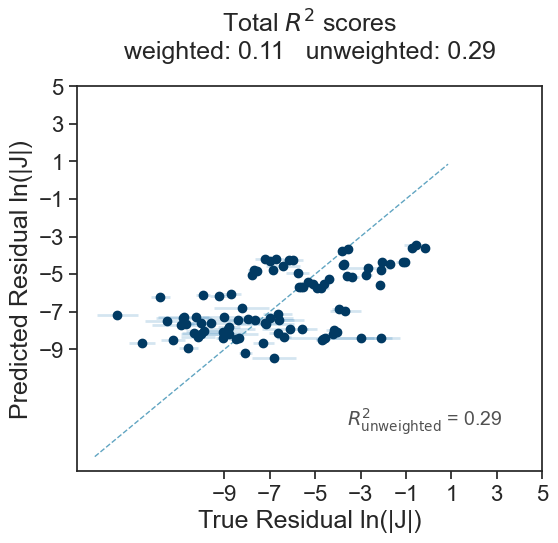

5
weighted_r2 0.11
adjusted_weighted_r2 0.06
unweighted_r2 0.29
adjusted_unweighted_r2 0.25


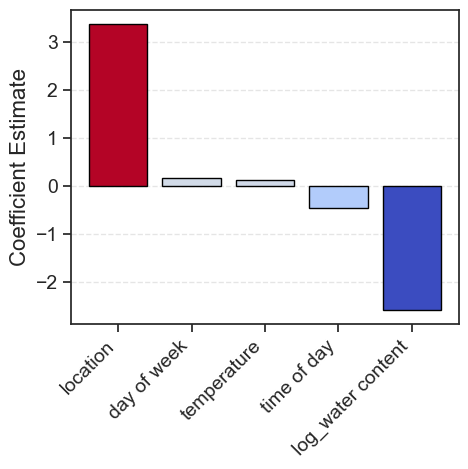

In [32]:
transformed_regressor = TransformedTargetRegressor(
    regressor=LinearRegression(),
    # transformer=RobustScaler()
)

ordinal_linear_pipeline = Pipeline([
    ("feature_scaling", linear_preprocess),
    ("model", transformed_regressor)
  ])

model = calculate_total_r2_score(ordinal_linear_pipeline, features=X_decay_baseline, target=y_true,heterosked_model=False,
                                  pure_residual_prediction=True,
                                  score_type="unweighted")

regressor = model.named_steps["model"].regressor_
# print(f"alpha {regressor.alpha_:0.2f}\tintercept{regressor.intercept_:0.2f}")

# for feat_name, coef in zip(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_):
#   print(f"{feat_name}: {coef:0.2f}")

draw_feature_importance(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_,figsize=(5,5),fontsize=16)

### Delta learning with linear features

In [33]:
X_baseline = dataset[[
    "location",
    # "electrode",
    # "carbon number",
    "temperature",
    "log_water content",
    "time of day",
    "day of week",
    # "day of year"
]]

In [34]:
X_baseline['location'].unique()

array(['Boston, Massachusetts', 'Ames, Iowa'], dtype=object)

In [35]:
linear_preprocess = ColumnTransformer(transformers=[
    ("continuous", RobustScaler(), [
        # "carbon number",
        "temperature",
        "log_water content",
        ##include the electrode and carbon length
    ]),

    ("time_day", time_scaler, ["time of day"]),
    ("day_week", week_scaler, ["day of week"]),
    # ("day_year", year_scaler, ["day of year"]),
    ("categorical", OrdinalEncoder(categories=[[ 'Boston, Massachusetts','Ames, Iowa']]), ["location"]),
    # ("categorical", OneHotEncoder(), ["location"]),
    ],verbose_feature_names_out=False)

#### Lasso

*Weighted + Combined prediction*

Weight applied


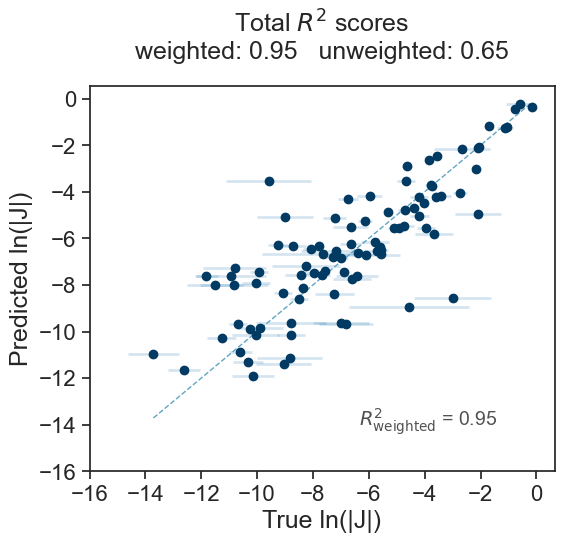

5
weighted_r2 0.95
adjusted_weighted_r2 0.95
unweighted_r2 0.65
adjusted_unweighted_r2 0.63
alpha 0.00	intercept0.00


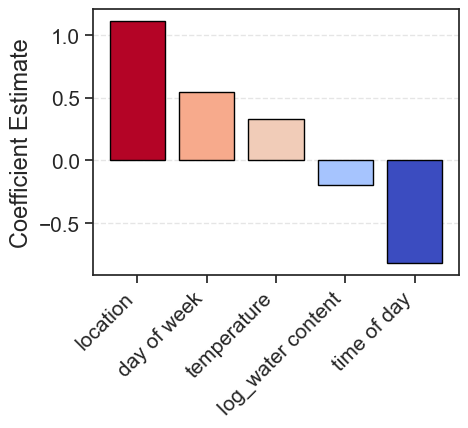

In [36]:
transformed_regressor = TransformedTargetRegressor(
    regressor=LassoCV(alphas=[1e-4, 1e-2, 1e-1, 0.5, 1e0, 1e1, 1e2, 1e3], fit_intercept=False, cv=skf),
    transformer=RobustScaler()
)

ordinal_lasso_pipeline = Pipeline([
    ("feature_scaling", linear_preprocess),
    ("model", transformed_regressor)
  ])

model = calculate_total_r2_score(ordinal_lasso_pipeline, features=X_baseline, heterosked_model=True, pure_residual_prediction=False)

regressor = model.named_steps["model"].regressor_
print(f"alpha {regressor.alpha_:0.2f}\tintercept{regressor.intercept_:0.2f}")

# for feat_name, coef in zip(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_):
#   print(f"{feat_name}: {coef:0.2f}")

draw_feature_importance(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_,figsize=(5,4.6),fontsize=17)

**Partial dependance plot** 

In [37]:
common_params = {
    "subsample": .99,
    "n_jobs": -1,
    "grid_resolution": 60,
    "random_state": 42,
}

print("Computing partial dependence plots...")
features_info = {
    # features of interest
    # "features": ["temp", "humidity", "windspeed", "season", "weather", "hour"],
    "features": [
        "day of week", "time of day",
       ("day of week", "time of day"),
        "temperature", "log_water content",
        ("temperature", "log_water content")
        ],
    # "custom_values":{

    # },
    # type of partial dependence plot
        # "kind": "average",
    "kind": ["both", "both", "average", "both", "both", "average"],
    # "subsample": 1,
    # "centered": True,

    # information regarding categorical features
    # "categorical_features": ["location"],
}

Computing partial dependence plots...


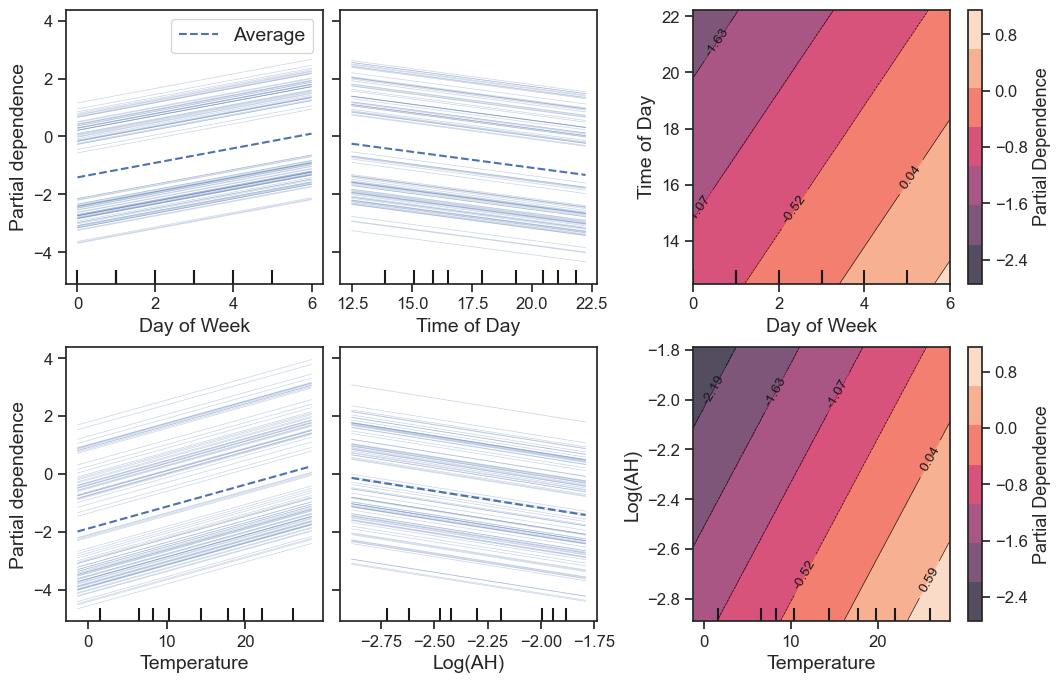

In [38]:
from sklearn.inspection import PartialDependenceDisplay
from matplotlib.ticker import MaxNLocator

# ---- Plot PDP ----
fig, ax = plt.subplots(ncols=3, nrows=2, figsize=(10.5, 6.8), constrained_layout=True)
display = PartialDependenceDisplay.from_estimator(
    model,
    X_baseline,
    **features_info,
    ax=ax,
    **common_params,
)

# ---- Label mapping ----
label_map = {
    "day of week": "Day of Week",
    "time of day": "Time of Day",
    "temperature": "Temperature",
    "log_water content": "Log(AH)",
}

# ---- Post-processing ----
first_legend_kept = False
for i, ax_row in enumerate(display.axes_):
    for j, a in enumerate(ax_row):
        if a is None:
            continue

        # ---- Format labels ----
        xlabel = a.get_xlabel()
        ylabel = a.get_ylabel()
        a.set_xlabel(label_map.get(xlabel, xlabel), fontsize=14)
        a.set_ylabel(label_map.get(ylabel, ylabel), fontsize=14)

        # ---- Remove top/right ticks ----
        # a.tick_params(which='both', top=False, right=False, left=True, bottom=True, direction='out')
        a.tick_params(axis='both',top=False, right=False, left=True, bottom=True, direction='out', labelsize=12)

        # ---- Keep only one legend ----
        legend = a.get_legend()
        if legend is not None:
            if not first_legend_kept:
                first_legend_kept = True
                for text in legend.get_texts():
                  text.set_text(text.get_text().capitalize())
                  text.set_fontsize(14)
            else:
                legend.remove()

        # ---- Add colorbar ONLY for 2D plots ----
        if display.contours_[i, j] is not None:
            cbar = fig.colorbar(display.contours_[i, j], ax=a)
            cbar.set_label("Partial Dependence", fontsize=13)
            cbar.ax.tick_params(labelsize=12)
            cbar.locator = MaxNLocator(nbins=5, prune='both')
            cbar.update_ticks()

# ---- Title ----
display.figure_.suptitle("", fontsize=17)

plt.show()

*Weighted + Residual score*

Weight applied


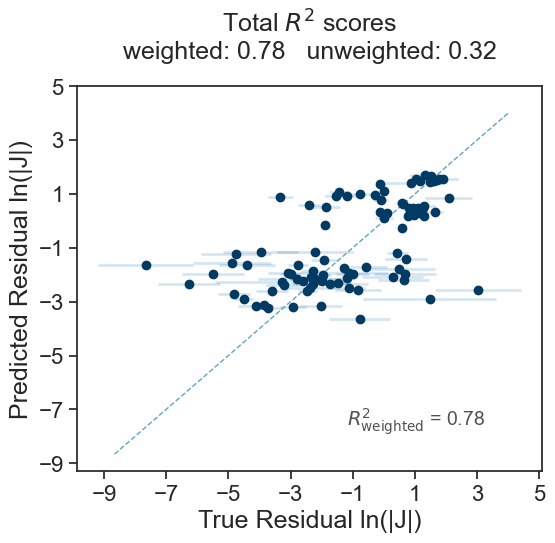

5
weighted_r2 0.78
adjusted_weighted_r2 0.77
unweighted_r2 0.32
adjusted_unweighted_r2 0.28
alpha 0.00	intercept0.00


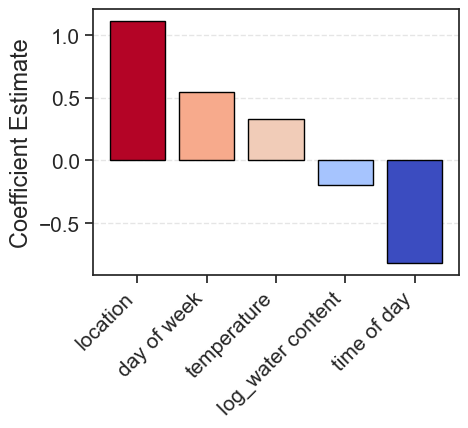

In [39]:
transformed_regressor = TransformedTargetRegressor(
    regressor=LassoCV(alphas=[1e-4, 1e-2, 1e-1, 0.5, 1e0, 1e1, 1e2, 1e3], fit_intercept=False, cv=skf),
    transformer=RobustScaler()
)

ordinal_lasso_pipeline = Pipeline([
    ("feature_scaling", linear_preprocess),
    ("model", transformed_regressor)
  ])

model = calculate_total_r2_score(ordinal_lasso_pipeline, features=X_baseline, heterosked_model=True, pure_residual_prediction=True)

regressor = model.named_steps["model"].regressor_
print(f"alpha {regressor.alpha_:0.2f}\tintercept{regressor.intercept_:0.2f}")

# for feat_name, coef in zip(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_):
#   print(f"{feat_name}: {coef:0.2f}")

draw_feature_importance(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_,figsize=(5,4.6),fontsize=17)

In [40]:
lasso_cv = model.named_steps["model"].regressor_
print("Selected alpha:", lasso_cv.alpha_)

Selected alpha: 0.0001


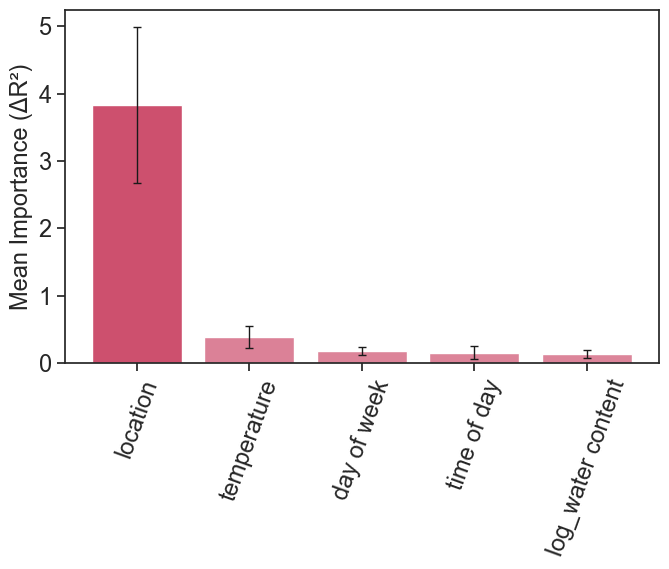

In [41]:
draw_permute_feature_imp(model, feat=X_baseline, target=y,sample_weight=y_weights, fontsize=17,figsize=(7,6) ,idx = [
    # ["electrode"],
    # ["carbon number"],
    ["location"],
    ["temperature"],
    ["time of day"],
    ["log_water content"],
    ["day of week"],
    # ["day of year"]
])


*Unweighted + combined score*

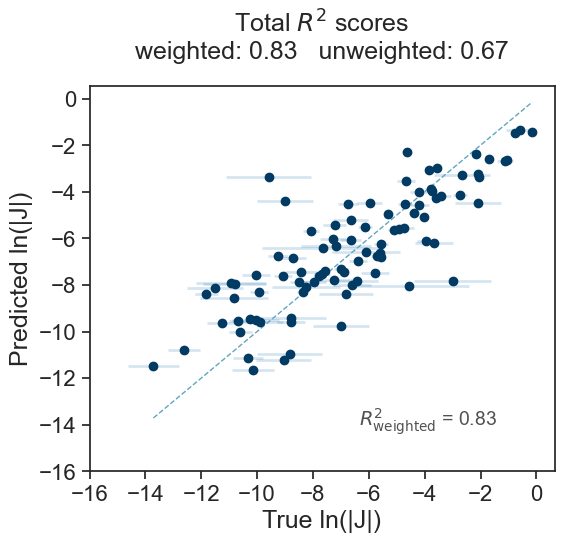

5
weighted_r2 0.83
adjusted_weighted_r2 0.82
unweighted_r2 0.67
adjusted_unweighted_r2 0.66
alpha 0.01	intercept0.00


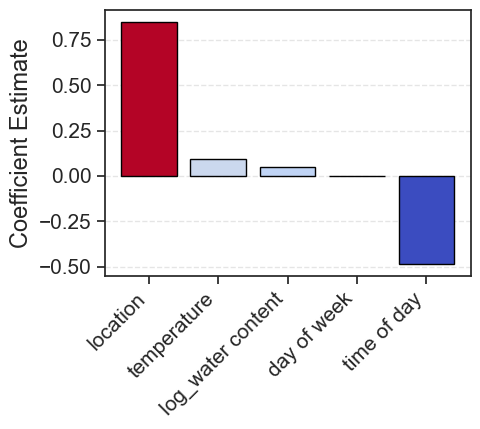

In [42]:
transformed_regressor = TransformedTargetRegressor(
    regressor=LassoCV(alphas=[1e-4, 1e-2, 1e-1, 0.5, 1e0, 1e1, 1e2, 1e3], fit_intercept=False, cv=skf),
    transformer=RobustScaler()
)

ordinal_lasso_pipeline = Pipeline([
    ("feature_scaling", linear_preprocess),
    ("model", transformed_regressor)
  ])

model = calculate_total_r2_score(ordinal_lasso_pipeline, features=X_baseline, heterosked_model=False)

regressor = model.named_steps["model"].regressor_
print(f"alpha {regressor.alpha_:0.2f}\tintercept{regressor.intercept_:0.2f}")

# for feat_name, coef in zip(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_):
#   print(f"{feat_name}: {coef:0.2f}")

draw_feature_importance(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_,figsize=(5,4.6),fontsize=17)

*structure of the pipeline*

In [43]:
model

,steps,"[('feature_scaling', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('continuous', ...), ('time_day', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


In [44]:
top_ordinal_Lasso_params = {
    "model__alpha": model['model'].regressor_.alpha_,
    # "model__l1_ratio": model['model'].regressor_.l1_ratio_
}

optimal_ordinal_Lasso_pipeline = Pipeline([
    ("feature_scaling", linear_preprocess),
    ("model", Lasso())
])
optimal_ordinal_Lasso_pipeline.set_params(**top_ordinal_Lasso_params)


,steps,"[('feature_scaling', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('continuous', ...), ('time_day', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,False


#### Ridge

Weighted

Weight applied


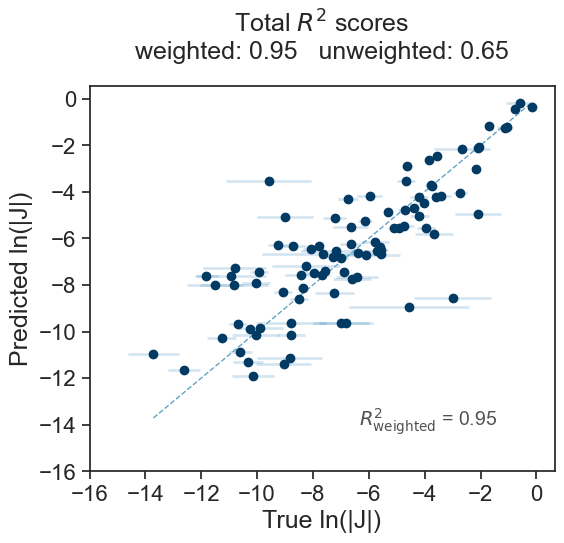

5
weighted_r2 0.95
adjusted_weighted_r2 0.95
unweighted_r2 0.65
adjusted_unweighted_r2 0.63
alpha 0.50	intercept0.00
temperature: 0.33
log_water content: -0.20
time of day: -0.82
day of week: 0.54
location: 1.11


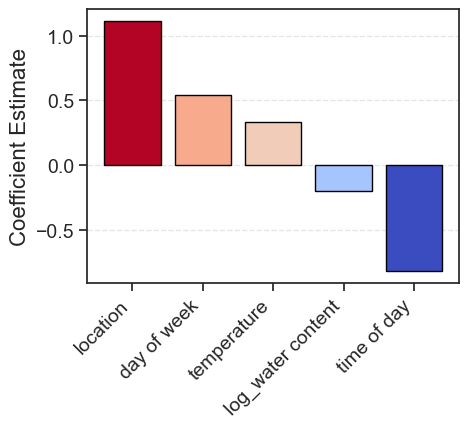

In [45]:
transformed_regressor = TransformedTargetRegressor(
    regressor=RidgeCV(alphas=[1e-4, 1e-2, 1e-1, 0.5, 1e0, 1e1, 1e2, 1e3], fit_intercept=False, cv=skf),
    transformer=RobustScaler()
)

ordinal_lasso_pipeline = Pipeline([
    ("feature_scaling", linear_preprocess),
    ("model", transformed_regressor)
  ])

model = calculate_total_r2_score(ordinal_lasso_pipeline, features=X_baseline,heterosked_model=True)

regressor = model.named_steps["model"].regressor_
print(f"alpha {regressor.alpha_:0.2f}\tintercept{regressor.intercept_:0.2f}")

for feat_name, coef in zip(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_):
  print(f"{feat_name}: {coef:0.2f}")

draw_feature_importance(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_,figsize=(5,4.6),fontsize=16)

In [46]:
ridge_cv = model.named_steps["model"].regressor_
print("Selected alpha:", ridge_cv.alpha_)

Selected alpha: 0.5


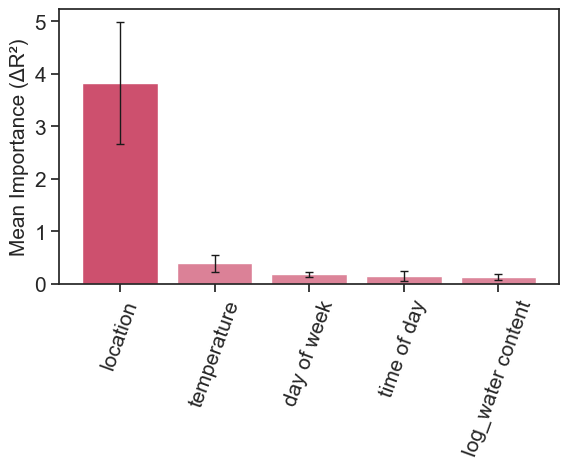

In [47]:
draw_permute_feature_imp(model, feat=X_baseline, target=y,sample_weight=y_weights, fontsize=15,figsize=(6,5) ,idx = [
    # ["electrode"],
    # ["carbon number"],
    ["location"],
    ["temperature"],
    ["time of day"],
    ["log_water content"],
    ["day of week"],
    # ["day of year"]
])

Unweighted

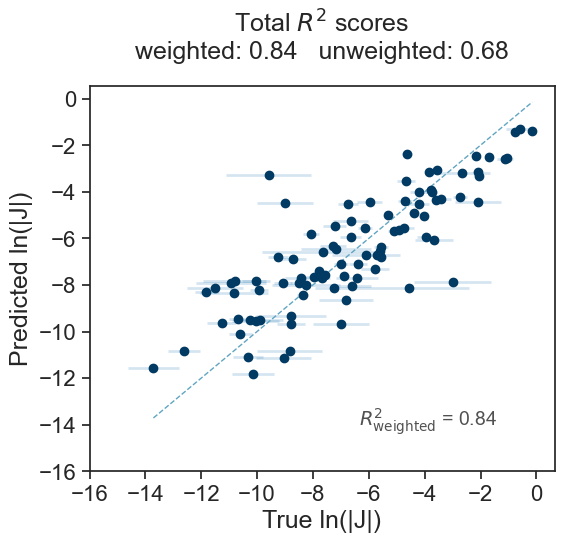

5
weighted_r2 0.84
adjusted_weighted_r2 0.84
unweighted_r2 0.68
adjusted_unweighted_r2 0.66
alpha 1.00	intercept0.00
temperature: 0.09
log_water content: 0.09
time of day: -0.58
day of week: 0.14
location: 0.89


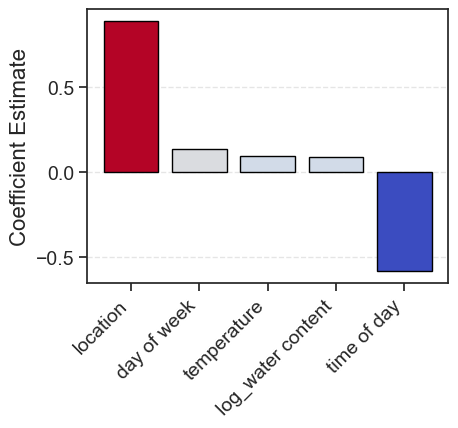

In [48]:
transformed_regressor = TransformedTargetRegressor(
    regressor=RidgeCV(alphas=[1e-4, 1e-2, 1e-1, 0.5, 1e0, 1e1, 1e2, 1e3], fit_intercept=False, cv=skf),
    transformer=RobustScaler()
)

ordinal_lasso_pipeline = Pipeline([
    ("feature_scaling", linear_preprocess),
    ("model", transformed_regressor)
  ])

model = calculate_total_r2_score(ordinal_lasso_pipeline, features=X_baseline,heterosked_model=False)

regressor = model.named_steps["model"].regressor_
print(f"alpha {regressor.alpha_:0.2f}\tintercept{regressor.intercept_:0.2f}")

for feat_name, coef in zip(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_):
  print(f"{feat_name}: {coef:0.2f}")

draw_feature_importance(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_,figsize=(5,4.6),fontsize=16)

#### ElasticNet

Weighted

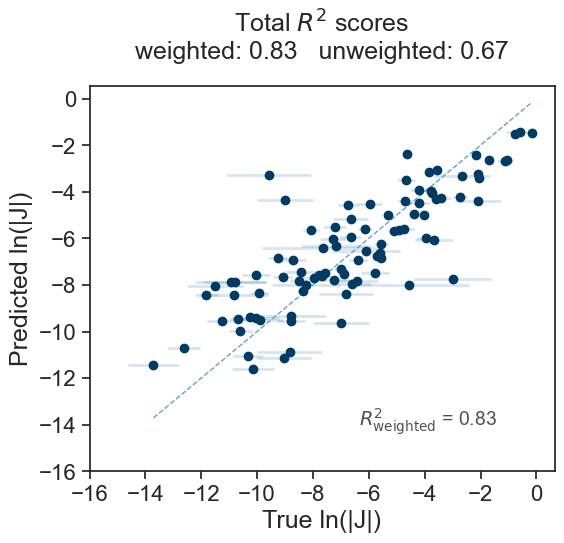

5
weighted_r2 0.83
adjusted_weighted_r2 0.81
unweighted_r2 0.67
adjusted_unweighted_r2 0.65
L1 ratio: 0.10	alpha 0.02	intercept0.00
temperature: 0.09
log_water content: 0.07
time of day: -0.48
day of week: 0.04
location: 0.81


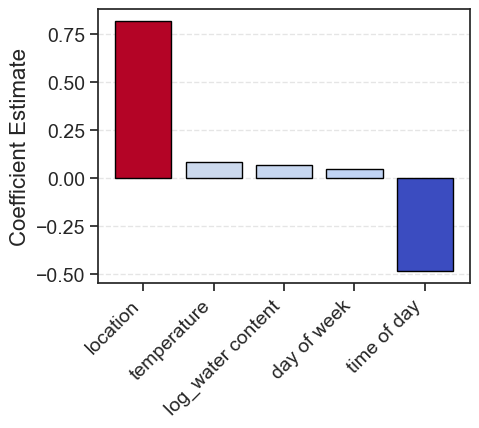

In [49]:
transformed_regressor = TransformedTargetRegressor(
    regressor=ElasticNetCV(l1_ratio=[1e-2, 1e-1, 0.5, 1e0], fit_intercept=False, ),
    transformer=RobustScaler()
)

ordinal_elasticnet_pipeline = Pipeline([
    ("feature_scaling", linear_preprocess),
    ("model", transformed_regressor)
])

model = calculate_total_r2_score(ordinal_elasticnet_pipeline, features=X_baseline, sample_weights=y_weights,heterosked_model=False)

regressor = model.named_steps["model"].regressor_
print(f"L1 ratio: {regressor.l1_ratio_:0.2f}\talpha {regressor.alpha_:0.2f}\tintercept{regressor.intercept_:0.2f}")

for feat_name, coef in zip(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_):
  print(f"{feat_name}: {coef:0.2f}")

draw_feature_importance(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_,figsize=(5,4.6),fontsize=16)

Weight applied


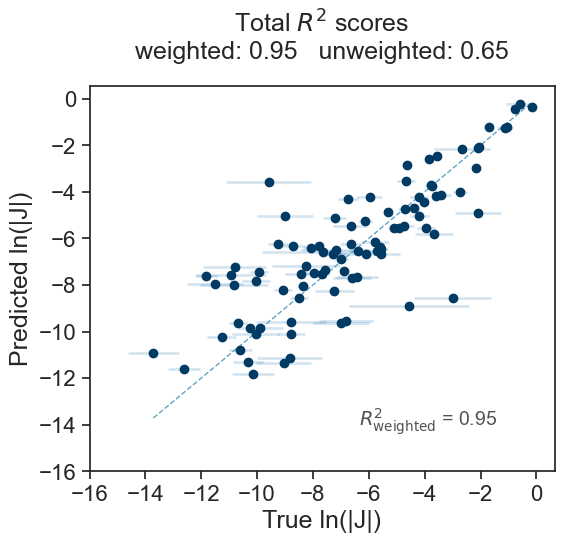

5
weighted_r2 0.95
adjusted_weighted_r2 0.95
unweighted_r2 0.65
adjusted_unweighted_r2 0.63
L1 ratio: 1.00	alpha 0.00	intercept0.00
temperature: 0.32
log_water content: -0.20
time of day: -0.79
day of week: 0.52
location: 1.09


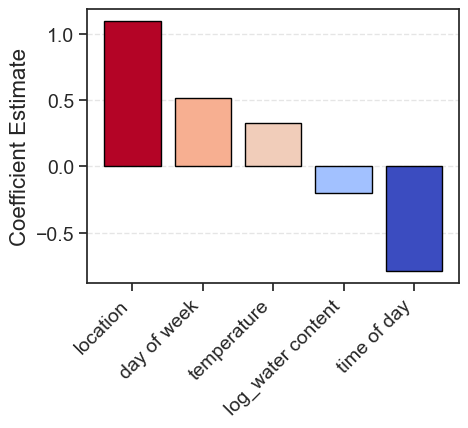

In [50]:
transformed_regressor = TransformedTargetRegressor(
    regressor=ElasticNetCV(l1_ratio=[1e-2, 1e-1, 0.5, 1e0], fit_intercept=False, ),
    transformer=RobustScaler()
)

ordinal_elasticnet_pipeline = Pipeline([
    ("feature_scaling", linear_preprocess),
    ("model", transformed_regressor)
])

model = calculate_total_r2_score(ordinal_elasticnet_pipeline, features=X_baseline, sample_weights=y_weights,heterosked_model=True)

regressor = model.named_steps["model"].regressor_
print(f"L1 ratio: {regressor.l1_ratio_:0.2f}\talpha {regressor.alpha_:0.2f}\tintercept{regressor.intercept_:0.2f}")

for feat_name, coef in zip(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_):
  print(f"{feat_name}: {coef:0.2f}")

draw_feature_importance(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_,figsize=(5,4.6),fontsize=16)

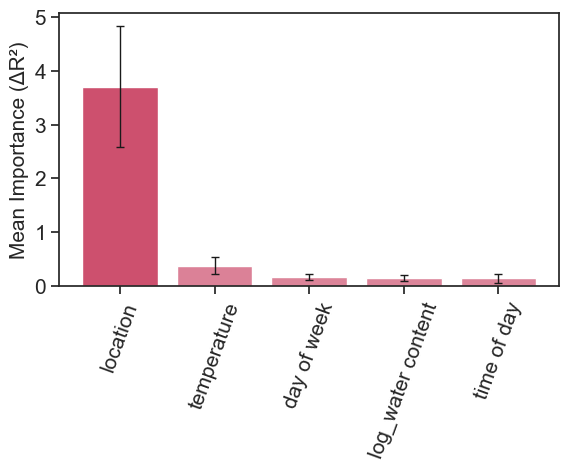

In [51]:
draw_permute_feature_imp(model, feat=X_baseline, target=y,sample_weight=y_weights, fontsize=15,figsize=(6,5) ,idx = [
    # ["electrode"],
    # ["carbon number"],
    ["location"],
    ["temperature"],
    ["time of day"],
    ["log_water content"],
    ["day of week"],
    # ["day of year"]
])

Unweighted

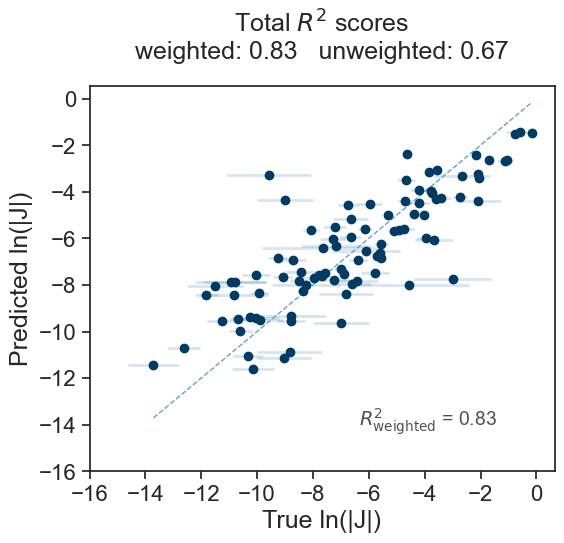

5
weighted_r2 0.83
adjusted_weighted_r2 0.81
unweighted_r2 0.67
adjusted_unweighted_r2 0.65
L1 ratio: 0.10	alpha 0.02	intercept0.00


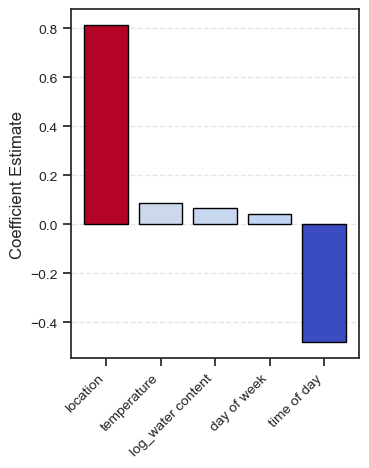

In [52]:
transformed_regressor = TransformedTargetRegressor(
    regressor=ElasticNetCV(l1_ratio=[1e-2, 1e-1, 0.5, 1e0], fit_intercept=False, ),
    transformer=RobustScaler()
)

ordinal_elasticnet_pipeline = Pipeline([
    ("feature_scaling", linear_preprocess),
    ("model", transformed_regressor)
])

model = calculate_total_r2_score(ordinal_elasticnet_pipeline, features=X_baseline, sample_weights=y_weights,heterosked_model=False)

regressor = model.named_steps["model"].regressor_
print(f"L1 ratio: {regressor.l1_ratio_:0.2f}\talpha {regressor.alpha_:0.2f}\tintercept{regressor.intercept_:0.2f}")

# for feat_name, coef in zip(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_):
#   print(f"{feat_name}: {coef:0.2f}")

draw_feature_importance(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_,figsize=(4,5))

#### Weighted Linear Regression

Weight applied


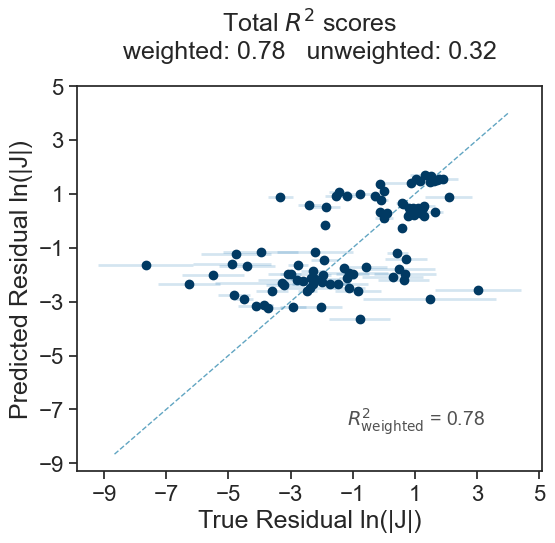

5
weighted_r2 0.78
adjusted_weighted_r2 0.77
unweighted_r2 0.32
adjusted_unweighted_r2 0.28
intercept: 0.00


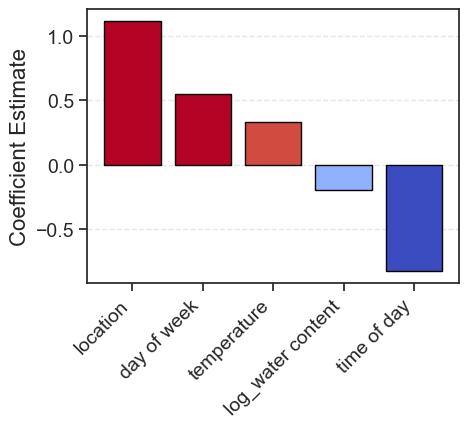

In [53]:
transformed_regressor = TransformedTargetRegressor(
    regressor=LinearRegression(fit_intercept=False),
    transformer=RobustScaler()
)

weighted_linear_pipeline = Pipeline([
    ("feature_scaling", linear_preprocess),
    ("model", transformed_regressor)
])

model = calculate_total_r2_score(weighted_linear_pipeline, features=X_baseline, heterosked_model=True,sample_weights=y_weights, pure_residual_prediction=True)

regressor = model.named_steps["model"].regressor_
print(f"intercept: {regressor.intercept_:0.2f}")

# for feat_name, coef in zip(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_):
#   print(f"{feat_name}: {coef:0.2f}")

draw_feature_importance(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_,figsize=(5,4.6),vmax=.4,vmin=-.4,fontsize=16)

Weight applied


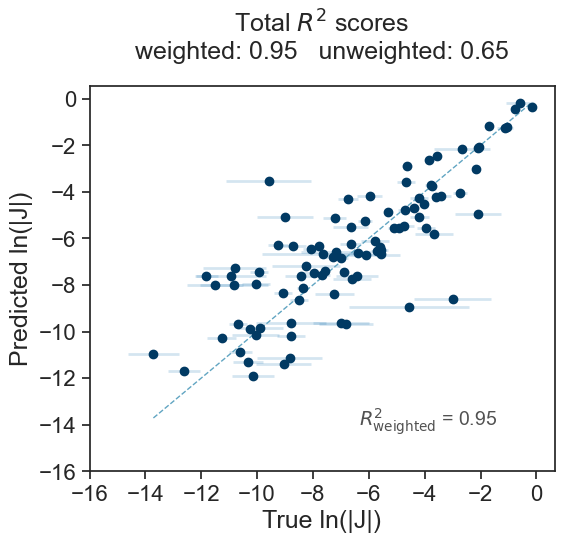

5
weighted_r2 0.95
adjusted_weighted_r2 0.95
unweighted_r2 0.65
adjusted_unweighted_r2 0.63
intercept: 0.00


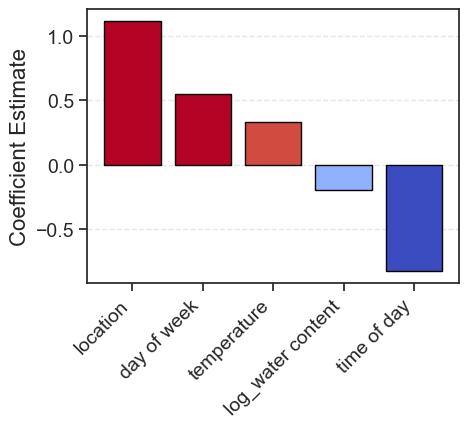

In [54]:
transformed_regressor = TransformedTargetRegressor(
    regressor=LinearRegression(fit_intercept=False),
    transformer=RobustScaler()
)

weighted_linear_pipeline = Pipeline([
    ("feature_scaling", linear_preprocess),
    ("model", transformed_regressor)
])

model = calculate_total_r2_score(weighted_linear_pipeline, features=X_baseline, heterosked_model=True,sample_weights=y_weights)

regressor = model.named_steps["model"].regressor_
print(f"intercept: {regressor.intercept_:0.2f}")

# for feat_name, coef in zip(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_):
#   print(f"{feat_name}: {coef:0.2f}")

draw_feature_importance(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_,figsize=(5,4.6),vmax=.4,vmin=-.4,fontsize=16)

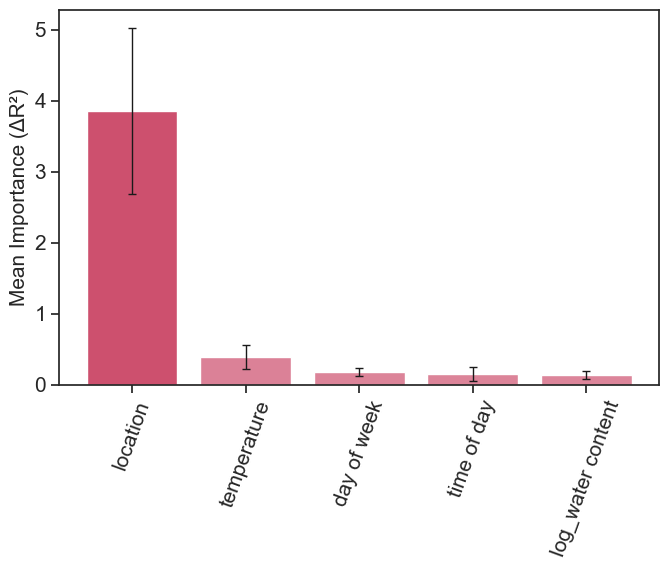

In [55]:
draw_permute_feature_imp(model, feat=X_baseline, target=y,sample_weight=y_weights, fontsize=15,figsize=(7,6) ,idx = [
    # ["electrode"],
    # ["carbon number"],
    ["location"],
    ["temperature"],
    ["time of day"],
    ["log_water content"],
    ["day of week"],
    # ["day of year"]
])

#### Aggregate result with linear features

In [56]:
def _draw_heatmap_scores(df_scores,
                         figsize=(4,3),
                         title=''):

  plt.figure(figsize=figsize)
  ax = sns.heatmap(df_scores, annot=True, cmap='viridis', fmt=".2f", cbar=True,annot_kws={"size": 15},vmax=1,vmin=0)
  cbar = ax.collections[0].colorbar
  cbar.set_label("R² score", fontsize=16,rotation=270,labelpad=18)
  plt.title(title,pad=20)
  plt.ylabel('')
  plt.xticks(rotation=45)
  plt.yticks(fontsize=12)
  plt.xlabel('Model')
  plt.tight_layout()
  plt.show()

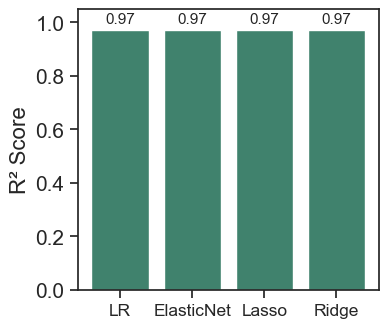

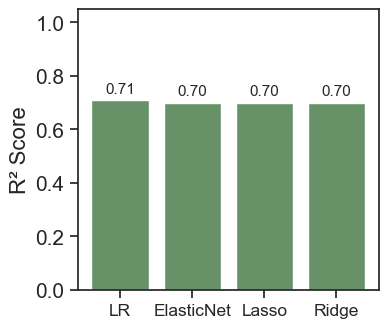

In [57]:
linear_results = {
    'LR': [0.97, 0.71],
    'ElasticNet': [0.97, 0.7],
    'Lasso': [0.97, 0.7],
    'Ridge': [0.97, 0.70],
}

index = ['Weighted', 'Unweighted']
df = pd.DataFrame(linear_results, index=index)

models = df.columns

# ---- Weighted ----
plt.figure(figsize=(4.2, 3.6))
bars = plt.bar(models, df.loc['Weighted'], color='#40826d')
plt.ylabel("R² Score", fontsize=16)
plt.xticks(fontsize=12.5, rotation=0)
plt.ylim(0, 1.05)

# Add annotations
for bar in bars:
    height = bar.get_height()
    plt.annotate(f"{height:.2f}",
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

# ---- Unweighted ----
plt.figure(figsize=(4.2, 3.6))
bars = plt.bar(models, df.loc['Unweighted'], color='#679267')
plt.ylabel("R² Score", fontsize=16)
plt.xticks(fontsize=12.5, rotation=0)
plt.ylim(0, 1.05)

# Add annotations
for bar in bars:
    height = bar.get_height()
    plt.annotate(f"{height:.2f}",
                 xy=(bar.get_x() + bar.get_width() / 2, height),
                 xytext=(0, 3),
                 textcoords="offset points",
                 ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

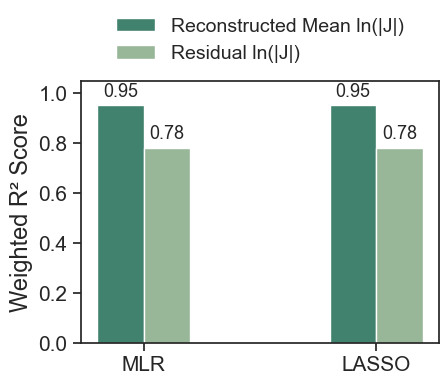

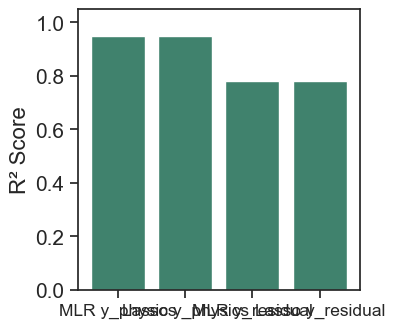

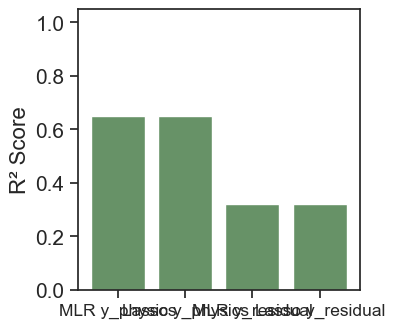

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

periodic_results = {
    'MLR y_physics': [0.95, .65],
    'LASSO y_physics': [.95, .65],
    'MLR y_residual': [0.78, .32],
    'LASSO y_residual': [.78, .32],
}

index = ['Weighted', 'Unweighted']
df = pd.DataFrame(periodic_results, index=index)

# --- Keep only Weighted ---
weighted = df.loc['Weighted']

# ---- Plot ----
fig, ax = plt.subplots(figsize=(4.8, 4))

models = ['MLR', 'LASSO']
x = np.arange(len(models))
bar_width = 0.2

mlr_vals = [weighted['MLR y_physics'], weighted['MLR y_residual']]
lasso_vals = [weighted['LASSO y_physics'], weighted['LASSO y_residual']]

bars1 = ax.bar(x[0] - bar_width/2, mlr_vals[0], width=bar_width,
               label='Reconstructed Mean ln(|J|)', color='#40826d')
bars2 = ax.bar(x[0] + bar_width/2, mlr_vals[1], width=bar_width,
               label='Residual ln(|J|)', color='#98B698')

bars3 = ax.bar(x[1] - bar_width/2, lasso_vals[0], width=bar_width,
               color='#40826d')
bars4 = ax.bar(x[1] + bar_width/2, lasso_vals[1], width=bar_width,
               color='#98B698')
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                height + 0.02,
                f"{height:.2f}",
                ha='center', va='bottom',
                fontsize=13)

ax.set_xticks(x)
ax.tick_params(axis='y', labelsize=15)
ax.set_xticklabels(models, fontsize=15)
ax.set_ylabel("Weighted R² Score", fontsize=17)
ax.set_ylim(0, 1.05)

# ---- Legend on top, outside ----
ax.legend(loc='lower center',
          bbox_to_anchor=(0.5, 1.0),
          ncol=1,
          fontsize=14,
          frameon=False)

plt.tight_layout()
plt.subplots_adjust(top=0.8)
plt.show()
import pandas as pd
import matplotlib.pyplot as plt

periodic_results = {
    'MLR y_physics': [0.95,.65],
    'Lasso y_physics': [.95,.65],
    'MLR y_residual': [0.78,.32],
    'Lasso y_residual': [.78,.32],

}

index = ['Weighted','Unweighted']
df = pd.DataFrame(periodic_results, index=index)

models = df.columns

# ---- Weighted ----
plt.figure(figsize=(4.2, 3.6))
plt.bar(models, df.loc['Weighted'], color='#40826d')
plt.ylabel("R² Score", fontsize=16)
# plt.title("Weighted", fontsize=13)
plt.xticks(fontsize=12.5, rotation=0)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# ---- Unweighted ----
plt.figure(figsize=(4.2, 3.6))
plt.bar(models, df.loc['Unweighted'], color='#679267')
plt.ylabel("R² Score", fontsize=16)
# plt.title("Unweighted", fontsize=13)
plt.xticks(fontsize=12.5, rotation=0)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

### Delta learning with trigonometrically transformed periodic features

In [59]:
periodic_preprocess = ColumnTransformer(transformers=[
    ("continuous", RobustScaler(), [
        # "carbon number",
        "temperature",
        "log_water content",
    ]),
    # ("time_day", time_scaler, ["time of day"]),
    ("periodic", "passthrough", ["hr_in_day_cos", "hr_in_day_sin", "day_in_week_cos", "day_in_week_sin",]),
    # ("day_week", week_scaler, ["day of week"]),
    ("categorical",  OrdinalEncoder(categories=[['Boston, Massachusetts','Ames, Iowa']]), ["location",])
    # ("categorical", OneHotEncoder(), ["location"])
],verbose_feature_names_out=False)

#### Lasso

*Wighted + residual score*

Weight applied


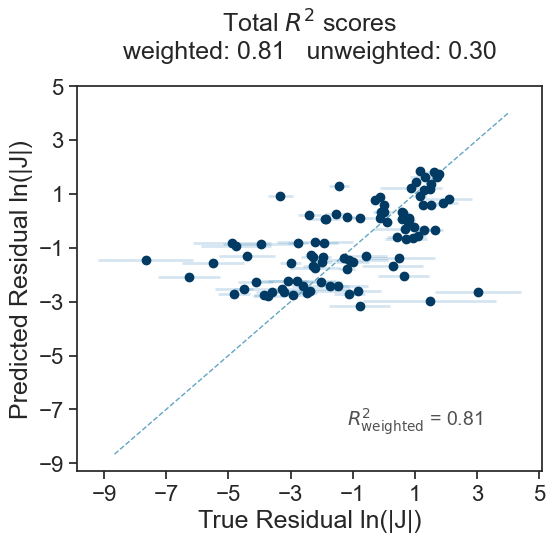

7
weighted_r2 0.81
adjusted_weighted_r2 0.8
unweighted_r2 0.3
adjusted_unweighted_r2 0.24
alpha 0.00	intercept0.00


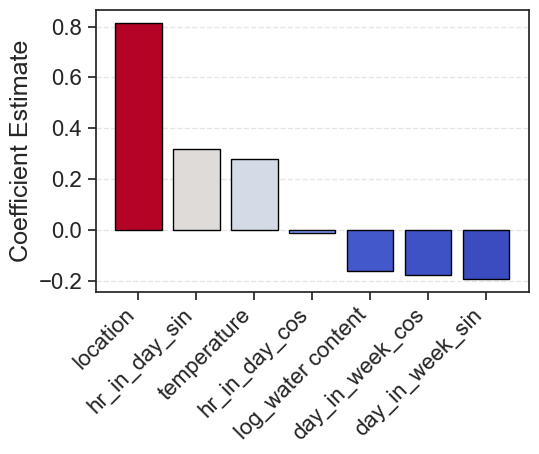

In [60]:
transformed_regressor = TransformedTargetRegressor(
    regressor=LassoCV(alphas=[1e-4, 1e-2, 1e-1, 0.5, 1e0, 1e1, 1e2, 1e3], fit_intercept=False, cv=skf),
    transformer=RobustScaler()
)

ordinal_lasso_pipeline = Pipeline([
    ("feature_scaling", periodic_preprocess),
    ("model", transformed_regressor)
  ])

model = calculate_total_r2_score(ordinal_lasso_pipeline, features=X_periodic, heterosked_model=True, pure_residual_prediction=True)

regressor = model.named_steps["model"].regressor_
print(f"alpha {regressor.alpha_:0.2f}\tintercept{regressor.intercept_:0.2f}")

# for feat_name, coef in zip(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_):
#   print(f"{feat_name}: {coef:0.2f}")

draw_feature_importance(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_,figsize=(5.7,4.85),fontsize=18)

*Weighted + Combined score*

Weight applied


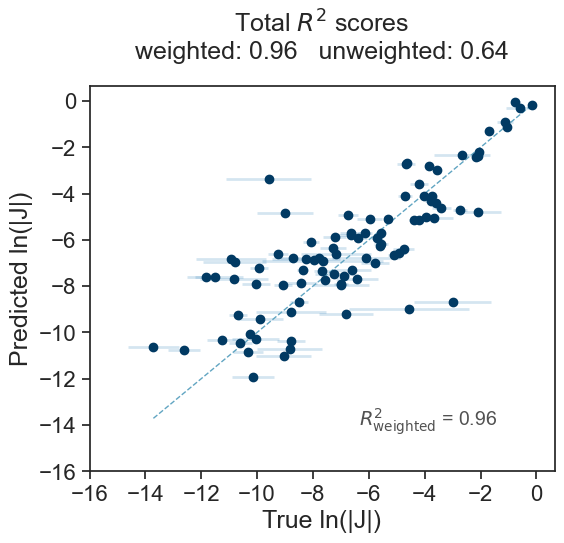

7
weighted_r2 0.96
adjusted_weighted_r2 0.95
unweighted_r2 0.64
adjusted_unweighted_r2 0.61
alpha 0.00	intercept0.00


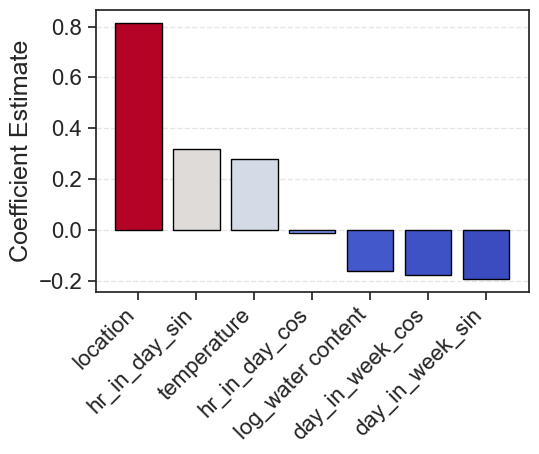

In [61]:
transformed_regressor = TransformedTargetRegressor(
    regressor=LassoCV(alphas=[1e-4, 1e-2, 1e-1, 0.5, 1e0, 1e1, 1e2, 1e3], fit_intercept=False, cv=skf),
    transformer=RobustScaler()
)

ordinal_lasso_pipeline = Pipeline([
    ("feature_scaling", periodic_preprocess),
    ("model", transformed_regressor)
  ])

model = calculate_total_r2_score(ordinal_lasso_pipeline, features=X_periodic, heterosked_model=True, pure_residual_prediction=False)

regressor = model.named_steps["model"].regressor_
print(f"alpha {regressor.alpha_:0.2f}\tintercept{regressor.intercept_:0.2f}")

# for feat_name, coef in zip(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_):
#   print(f"{feat_name}: {coef:0.2f}")

draw_feature_importance(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_,figsize=(5.7,4.85),fontsize=18)

In [62]:
lasso_cv = model.named_steps["model"].regressor_
print("Selected alpha:", lasso_cv.alpha_)


Selected alpha: 0.0001


In [63]:
X_periodic.columns.to_list()

['location',
 'electrode',
 'temperature',
 'log_water content',
 'hr_in_day_cos',
 'hr_in_day_sin',
 'day_in_week_cos',
 'day_in_week_sin']

Single feature permutation importance

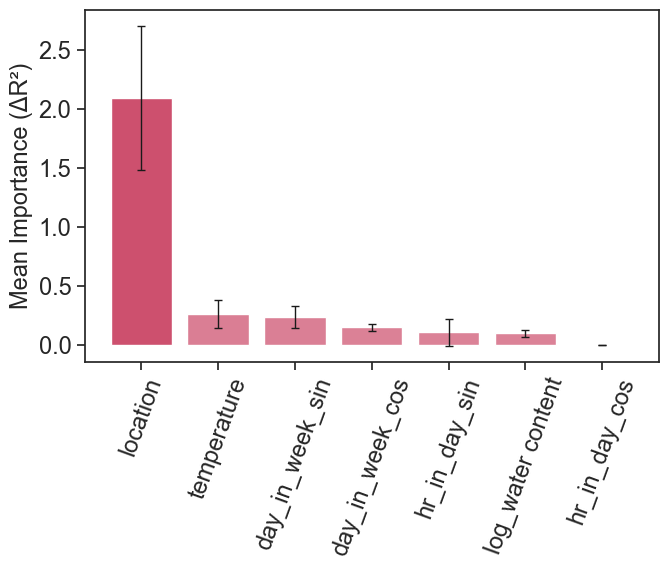

In [64]:
draw_permute_feature_imp(model, feat=X_periodic, target=y,sample_weight=y_weights, figsize=(7,6), fontsize=17,idx = [
    ["location"],                    # group 2
    # ["electrode"],
    ["temperature"],  # group 1
    ["log_water content"],
    ["hr_in_day_cos"],
    ["hr_in_day_sin"],
    ["day_in_week_cos"],
    ["day_in_week_sin"]
])

*Group-wise feature permutation importance*

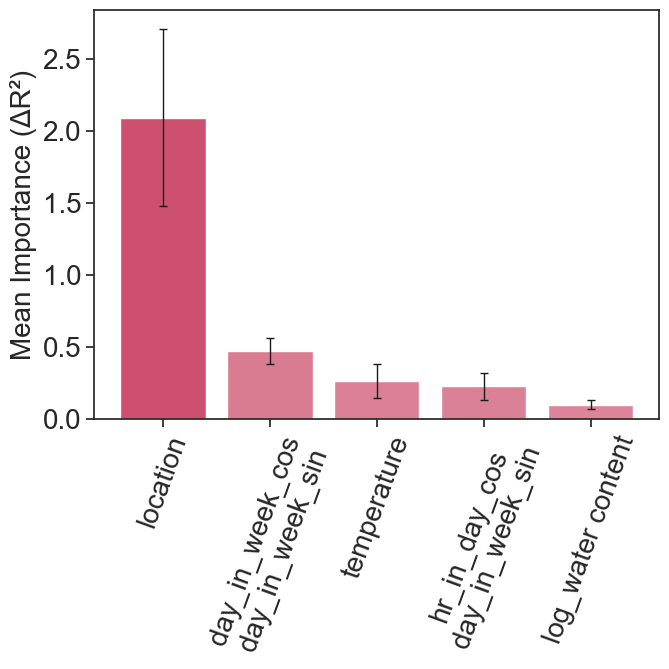

In [65]:
draw_permute_feature_imp(model, feat=X_periodic, target=y,sample_weight=y_weights,figsize=(7,7), fontsize=20,idx = [
    ["location"],                    # group 2
    # ["electrode"],
    ["temperature"],  # group 1
    ["log_water content"],
    ["hr_in_day_cos","day_in_week_sin"],
    # ["hr_in_day_sin"],
    ["day_in_week_cos","day_in_week_sin"],
    # []
])

**Partial Dependence Plots**

In [66]:
common_params = {
    "subsample": .99,
    "n_jobs": -1,
    "grid_resolution": 50,
    "random_state": 42,
}

print("Computing partial dependence plots...")
features_info = {
    "features": [
        "hr_in_day_cos", "hr_in_day_sin",
       ("hr_in_day_cos", "hr_in_day_sin"),
        "day_in_week_cos", "day_in_week_sin",
        ("day_in_week_cos", "day_in_week_sin"),
        # "temperature", "log_water content",
        # ("temperature", "log_water content")
        ],
    # type of partial dependence plot
      "kind": ["both", "both", "average", "both", "both", "average"],
    # "centered": True,
    # information regarding categorical features
    # "categorical_features": ["location"],
}

Computing partial dependence plots...


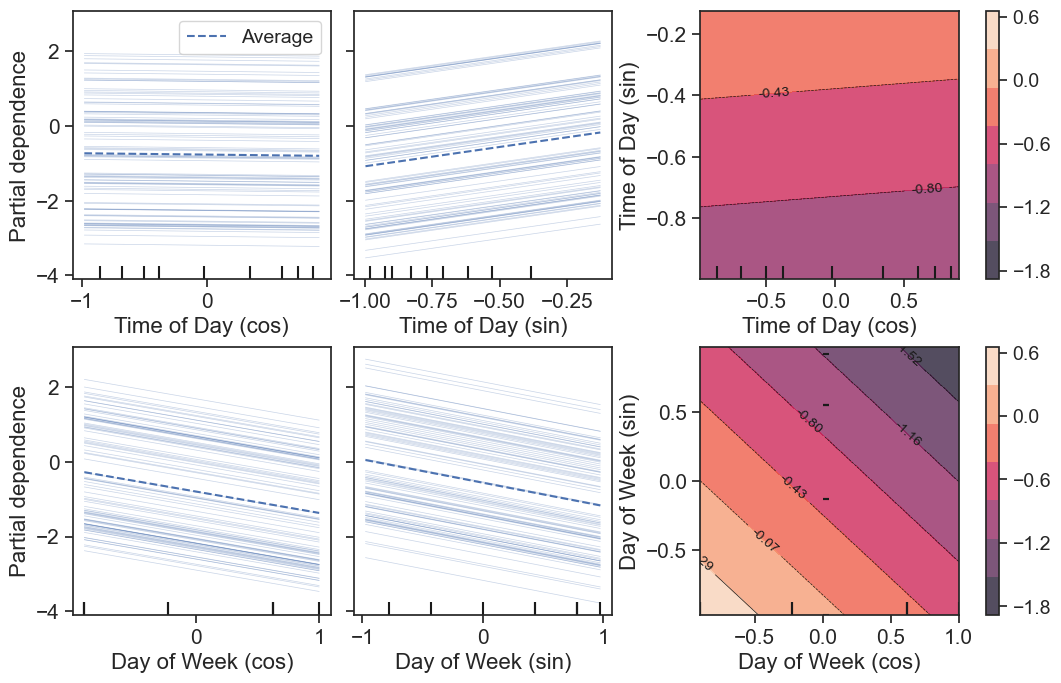

In [67]:
# ---- Plot PDP ----
fig, ax = plt.subplots(ncols=3, nrows=2, figsize=(10.5, 6.8), constrained_layout=True)
display = PartialDependenceDisplay.from_estimator(
    model,
    X_periodic,
    **features_info,
    ax=ax,
    **common_params,
)

# ---- Label mapping ----
label_map = {
    "hr_in_day_cos": "Time of Day (cos)",
    "hr_in_day_sin": "Time of Day (sin)",
    "day_in_week_cos": "Day of Week (cos)",
    "day_in_week_sin": "Day of Week (sin)",
}

# ---- Post-processing ----
first_legend_kept = False
for i, ax_row in enumerate(display.axes_):
    for j, a in enumerate(ax_row):
        if a is None:
            continue

        # ---- Format labels ----
        xlabel = a.get_xlabel()
        ylabel = a.get_ylabel()
        a.set_xlabel(label_map.get(xlabel, xlabel), fontsize=16)
        a.set_ylabel(label_map.get(ylabel, ylabel), fontsize=16)

        # ---- Remove top/right ticks ----
        a.tick_params(axis='x', top=False, right=False, left=True, bottom=True, direction='out')

        # ---- Keep only one legend ----
        legend = a.get_legend()
        if legend is not None:
            if not first_legend_kept:
                first_legend_kept = True
                for text in legend.get_texts():
                    text.set_text(text.get_text().capitalize())
            else:
                legend.remove()

        # ---- Add colorbar ONLY for 2D plots ----
        if display.contours_[i, j] is not None:
            cbar = fig.colorbar(display.contours_[i, j], ax=a)
            cbar.ax.tick_params(labelsize=14)
            cbar.locator = MaxNLocator(nbins=5, prune='both')
            cbar.update_ticks()

# ---- Title ----
display.figure_.suptitle("", fontsize=17)

plt.show()

**Polar projection of partial dependence (Sin and Cos)**

In [68]:
from sklearn.inspection import partial_dependence

features = ("hr_in_day_cos", "hr_in_day_sin")

cos_all = X_periodic["hr_in_day_cos"].values
sin_all = X_periodic["hr_in_day_sin"].values

pdp = partial_dependence(
    model,
    X_periodic,
    features=features,
    kind="individual",
    custom_values={
        "hr_in_day_cos": cos_all,
        "hr_in_day_sin": sin_all,
    }
)

# ── 2. Reshape Z_avg into 2D grid ─────────────────────────────────────────────
# sklearn deduplicates custom_values → actual grid may be smaller than n × n
cos_grid = pdp["grid_values"][0]   # deduplicated cos values
sin_grid = pdp["grid_values"][1]   # deduplicated sin values

Z = pdp.individual[0]              # (n_samples, len(cos_grid) * len(sin_grid))
Z_avg = np.mean(Z, axis=0)        # (len(cos_grid) * len(sin_grid),)
Z_avg_2d = Z_avg.reshape(len(cos_grid), len(sin_grid))  # 2D lookup table

# ── 3. Map each data point to its nearest grid index ─────────────────────────
cos_idx = np.array([np.argmin(np.abs(cos_grid - v)) for v in cos_all])
sin_idx = np.array([np.argmin(np.abs(sin_grid - v)) for v in sin_all])

Z_real = Z_avg_2d[cos_idx, sin_idx]   # (n_samples,)

# ── 4. Angle and plot ─────────────────────────────────────────────────────────
theta = np.arctan2(sin_all, cos_all)

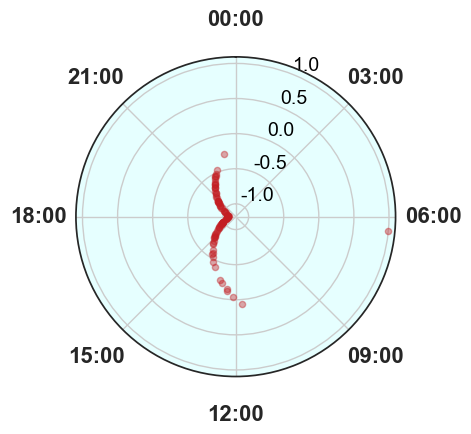

In [69]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(projection="polar")
ax.set_facecolor("#E6FFFF")

# ── Clock orientation ─────────────────────────────────────────────────────────
ax.set_theta_zero_location('N')   # 00:00 at top  (like 12 on a clock)
ax.set_theta_direction(-1)        # angles increase clockwise

ax.scatter(theta, np.round(Z_real, 2), color="#c31e23", s=20, alpha=0.4)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}"))
ax.set_rlabel_position(22)          # labels sit on the top spoke
ax.tick_params(axis='y', labelsize=14, labelcolor="black", pad=-22)
# ax.set_yticklabels([])   # ← removes radial labels entirely


# ── Clock-face hour ticks (every 3 h → 8 labels around the dial) ─────────────
hour_step = 3                                    # change to 1 for every hour
hours     = np.arange(0, 24, hour_step)
angles_deg = hours * (360 / 24)                  # 15° per hour; 0° = midnight = top
labels    = [f"{h:02d}:00" for h in hours]

ax.set_thetagrids(
    angles_deg,
    labels=labels,
    fontweight='bold',
    fontsize=16,
)
ax.tick_params(axis='x', pad=14)

plt.tight_layout()
plt.show()

In [70]:
features = ("day_in_week_cos", "day_in_week_sin")

cos_all = X_periodic["day_in_week_cos"].values
sin_all = X_periodic["day_in_week_sin"].values

pdp = partial_dependence(
    model,
    X_periodic,
    features=features,
    kind="individual",
    custom_values={
        "day_in_week_cos": cos_all,
        "day_in_week_sin": sin_all,
    }
)

# ── 2. Reshape Z_avg into 2D grid ─────────────────────────────────────────────
# sklearn deduplicates custom_values → actual grid may be smaller than n × n
cos_grid = pdp["grid_values"][0]   # deduplicated cos values
sin_grid = pdp["grid_values"][1]   # deduplicated sin values

Z = pdp.individual[0]              # (n_samples, len(cos_grid) * len(sin_grid))
Z_avg = np.mean(Z, axis=0)        # (len(cos_grid) * len(sin_grid),)
Z_avg_2d = Z_avg.reshape(len(cos_grid), len(sin_grid))  # 2D lookup table

# ── 3. Map each data point to its nearest grid index ─────────────────────────
cos_idx = np.array([np.argmin(np.abs(cos_grid - v)) for v in cos_all])
sin_idx = np.array([np.argmin(np.abs(sin_grid - v)) for v in sin_all])

Z_real = Z_avg_2d[cos_idx, sin_idx]   # (n_samples,)

# ── 4. Angle and plot ─────────────────────────────────────────────────────────
theta = np.arctan2(sin_all, cos_all)

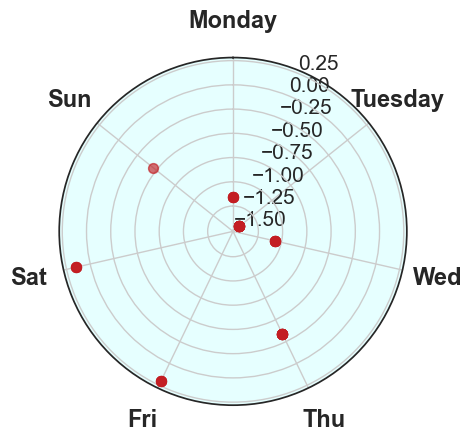

In [71]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(projection="polar")
ax.set_facecolor("#E6FFFF")

# ── Clock orientation ─────────────────────────────────────────────────────────
ax.set_theta_zero_location('N')   # Monday at top
ax.set_theta_direction(-1)        # clockwise

ax.scatter(theta, np.round(Z_real, 2), color="#c31e23", s=50, alpha=0.4)

# ── Day labels ────────────────────────────────────────────────────────────────
angles = np.linspace(0, 360, 7, endpoint=False)   # 0°, ~51°, ~103° … in display coords
ax.set_thetagrids(
    angles,
    labels=["Monday", "Tuesday", "Wed", "Thu", "Fri", "Sat", "Sun"],
    fontweight="bold",
    fontsize=17,
)

# ── Radial labels: remove entirely ───────────────────────────────────────────
# ax.set_yticklabels([])

ax.tick_params(axis='x', pad=13)
plt.tight_layout()
plt.show()

#### Ridge

*Weighted*

Weight applied


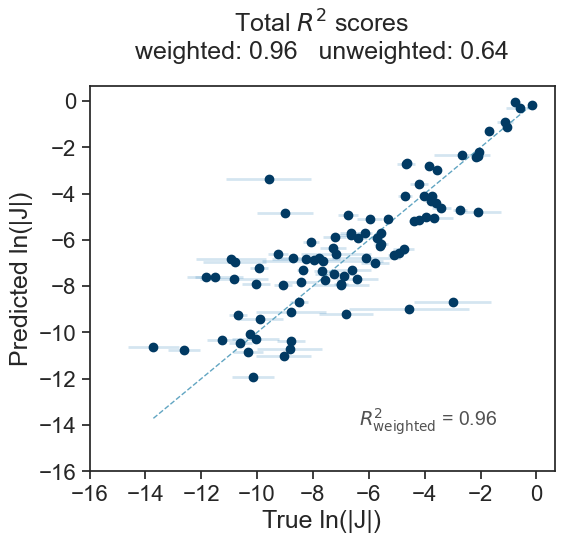

7
weighted_r2 0.96
adjusted_weighted_r2 0.95
unweighted_r2 0.64
adjusted_unweighted_r2 0.61
alpha 1.00	intercept0.00


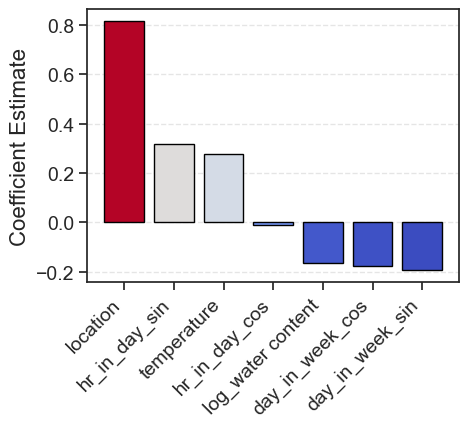

In [72]:
transformed_regressor = TransformedTargetRegressor(
    regressor=RidgeCV(alphas=[1e-4, 1e-2, 1e-1, 0.5, 1e0, 1e1, 1e2, 1e3], fit_intercept=False, cv=skf),
    transformer=RobustScaler()
)

ordinal_lasso_pipeline = Pipeline([
    ("feature_scaling", periodic_preprocess),
    ("model", transformed_regressor)
  ])

model = calculate_total_r2_score(ordinal_lasso_pipeline, features=X_periodic,heterosked_model=True)

regressor = model.named_steps["model"].regressor_
print(f"alpha {regressor.alpha_:0.2f}\tintercept{regressor.intercept_:0.2f}")

# for feat_name, coef in zip(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_):
#   print(f"{feat_name}: {coef:0.2f}")

# draw_feature_importance(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_,figsize=(5,4.6),fontsize=16)
draw_feature_importance(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_,figsize=(5,4.6),fontsize=16)

In [73]:
ridge_cv = model.named_steps["model"].regressor_
print("Selected alpha:", ridge_cv.alpha_)


Selected alpha: 1.0


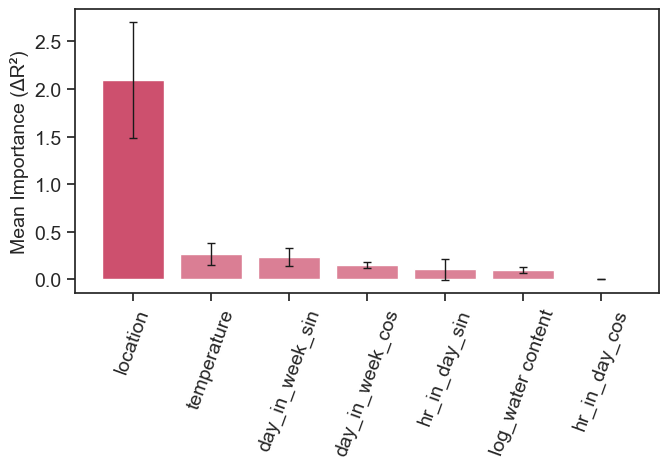

In [74]:
draw_permute_feature_imp(model, feat=X_periodic, target=y,sample_weight=y_weights,figsize=(7,5), fontsize=14,idx = [
    ["location"],                    # group 2
    # ["electrode"],
    ["temperature"],  # group 1
    ["log_water content"],
    ["hr_in_day_cos"],
     ["day_in_week_sin"],
    ["hr_in_day_sin"],
    ["day_in_week_cos"],
    # []
])

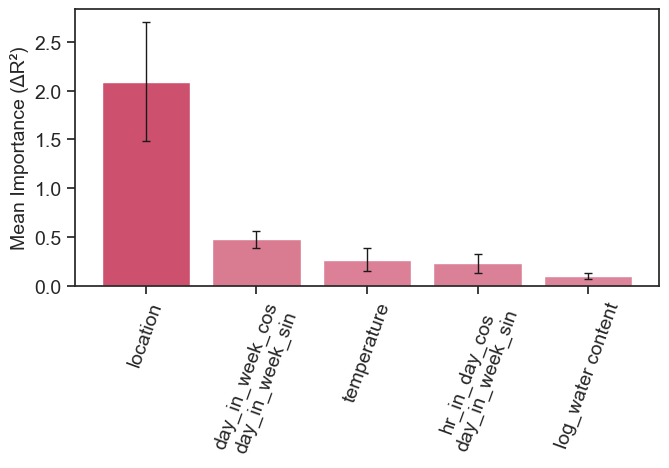

In [75]:
draw_permute_feature_imp(model, feat=X_periodic, target=y,sample_weight=y_weights,figsize=(7,5), fontsize=14,idx = [
    ["location"],                    # group 2
    # ["electrode"],
    ["temperature"],  # group 1
    ["log_water content"],
    ["hr_in_day_cos","day_in_week_sin"],
    # ["hr_in_day_sin"],
    ["day_in_week_cos","day_in_week_sin"],
    # []
])

#### ElasticNet

*Weighted + Combined score*

Weight applied


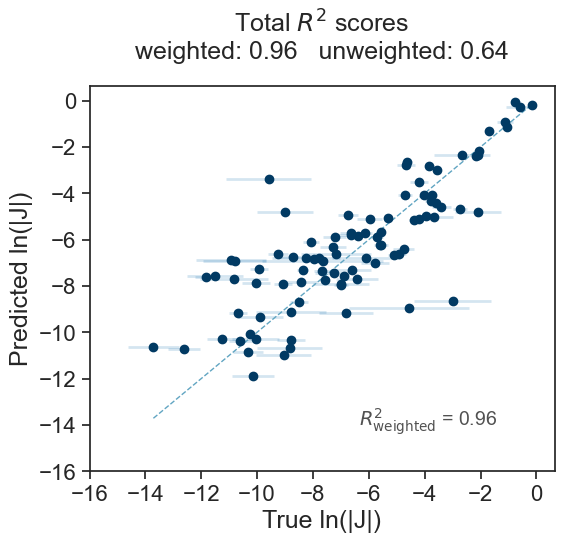

7
weighted_r2 0.96
adjusted_weighted_r2 0.95
unweighted_r2 0.64
adjusted_unweighted_r2 0.61
L1 ratio: 1.00	alpha 0.00	intercept0.00


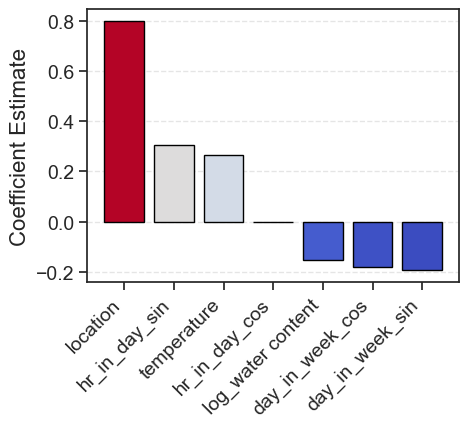

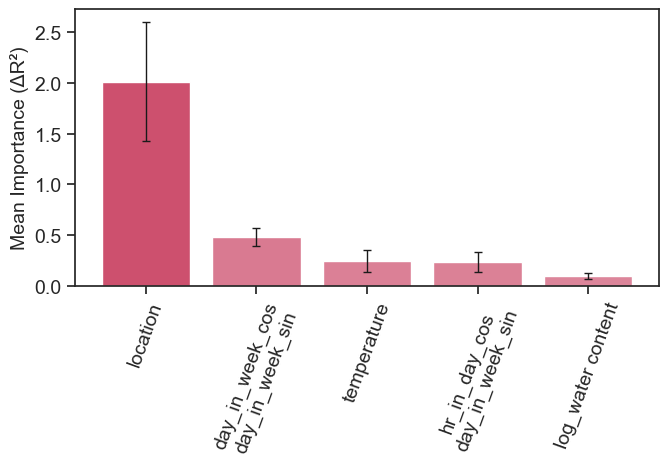

In [76]:
transformed_regressor = TransformedTargetRegressor(
    regressor=ElasticNetCV(l1_ratio=[1e-2, 1e-1, 0.5, 1e0], fit_intercept=False),
    transformer=RobustScaler()
)

ordinal_elasticnet_pipeline = Pipeline([
    ("feature_scaling", periodic_preprocess),
    ("model", transformed_regressor)
])

model = calculate_total_r2_score(ordinal_elasticnet_pipeline, features=X_periodic, sample_weights=y_weights,heterosked_model=True)

regressor = model.named_steps["model"].regressor_
print(f"L1 ratio: {regressor.l1_ratio_:0.2f}\talpha {regressor.alpha_:0.2f}\tintercept{regressor.intercept_:0.2f}")

# for feat_name, coef in zip(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_):
#   print(f"{feat_name}: {coef:0.2f}")

draw_feature_importance(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_,figsize=(5,4.6),fontsize=16)
draw_permute_feature_imp(model, feat=X_periodic, target=y,sample_weight=y_weights,figsize=(7,5), fontsize=14,idx = [
    ["location"],                    # group 2
    # ["electrode"],
    ["temperature"],  # group 1
    ["log_water content"],
    ["hr_in_day_cos","day_in_week_sin"],
    # ["hr_in_day_sin"],
    ["day_in_week_cos","day_in_week_sin"],
    # []
])

#### Weighted Linear Regression

*Weighted + residual score*

Weight applied


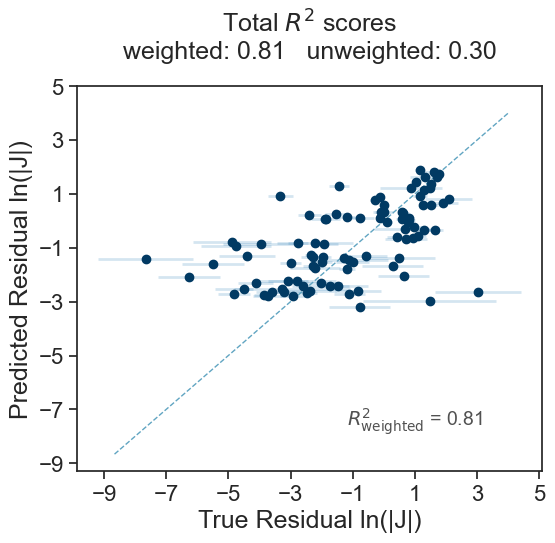

7
weighted_r2 0.81
adjusted_weighted_r2 0.8
unweighted_r2 0.3
adjusted_unweighted_r2 0.24
intercept: 0.00


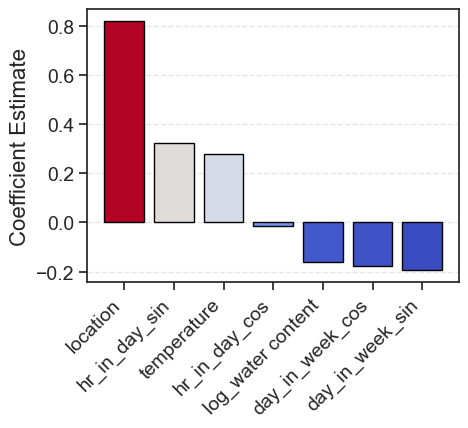

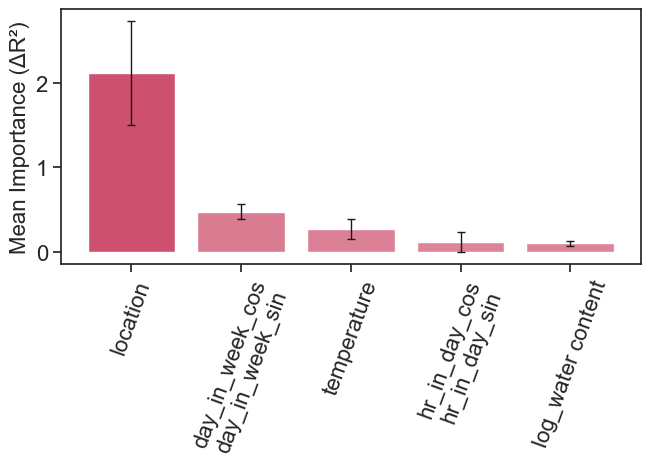

In [77]:
transformed_regressor = TransformedTargetRegressor(
    regressor=LinearRegression(fit_intercept=False),
    transformer=RobustScaler()
)

weighted_linear_pipeline = Pipeline([
    ("feature_scaling", periodic_preprocess),
    ("model", transformed_regressor)
])

model = calculate_total_r2_score(weighted_linear_pipeline, features=X_periodic, sample_weights=y_weights,heterosked_model=True, pure_residual_prediction=True)



regressor = model.named_steps["model"].regressor_
print(f"intercept: {regressor.intercept_:0.2f}")

# for feat_name, coef in zip(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_):
#   print(f"{feat_name}: {coef:0.2f}")

draw_feature_importance(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_,figsize=(5,4.6),fontsize=16)
draw_permute_feature_imp(model, feat=X_periodic, target=y,sample_weight=y_weights,figsize=(7,5), fontsize=16,idx = [
    ["location"],                    # group 2
    # ["electrode"],
    ["temperature"],  # group 1
    ["log_water content"],
    ["hr_in_day_cos","hr_in_day_sin"],
    # ["hr_in_day_sin"],
    ["day_in_week_cos","day_in_week_sin"],
    # []
])

*Weighted + combined score*

Weight applied


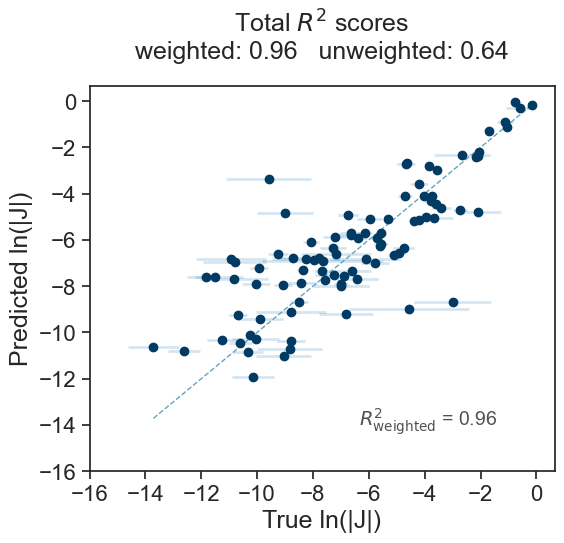

7
weighted_r2 0.96
adjusted_weighted_r2 0.95
unweighted_r2 0.64
adjusted_unweighted_r2 0.61
intercept: 0.00


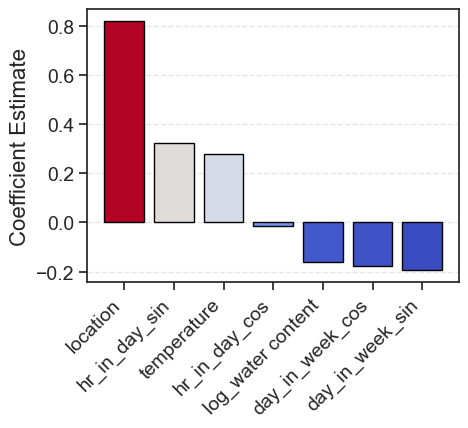

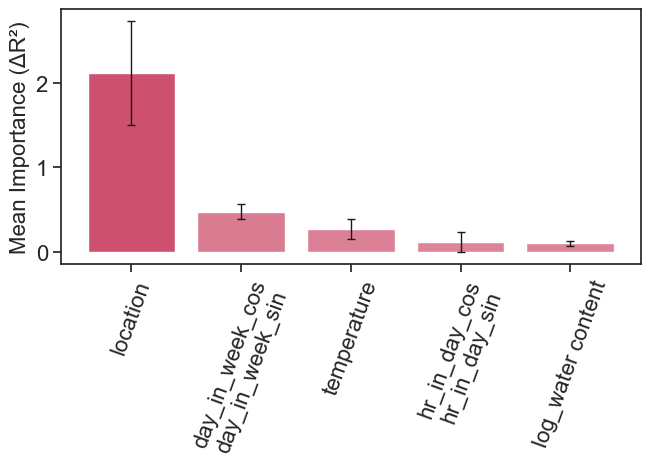

In [78]:
transformed_regressor = TransformedTargetRegressor(
    regressor=LinearRegression(fit_intercept=False),
    transformer=RobustScaler()
)

weighted_linear_pipeline = Pipeline([
    ("feature_scaling", periodic_preprocess),
    ("model", transformed_regressor)
])

model = calculate_total_r2_score(weighted_linear_pipeline, features=X_periodic, sample_weights=y_weights,heterosked_model=True)



regressor = model.named_steps["model"].regressor_
print(f"intercept: {regressor.intercept_:0.2f}")

# for feat_name, coef in zip(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_):
#   print(f"{feat_name}: {coef:0.2f}")

draw_feature_importance(model.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_,figsize=(5,4.6),fontsize=16)
draw_permute_feature_imp(model, feat=X_periodic, target=y,sample_weight=y_weights,figsize=(7,5), fontsize=16,idx = [
    ["location"],                    # group 2
    # ["electrode"],
    ["temperature"],  # group 1
    ["log_water content"],
    ["hr_in_day_cos","hr_in_day_sin"],
    # ["hr_in_day_sin"],
    ["day_in_week_cos","day_in_week_sin"],
    # []
])

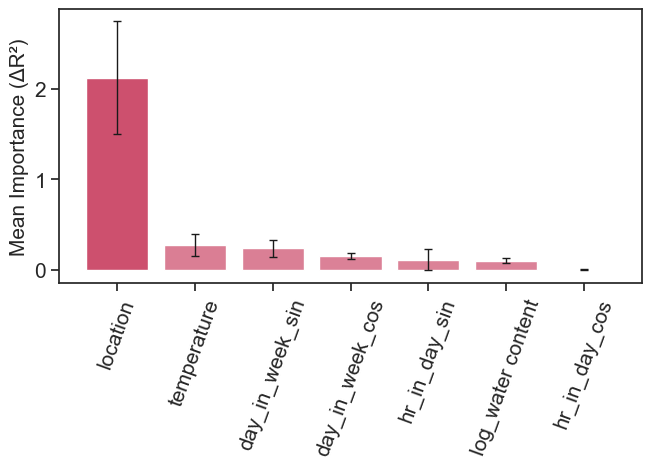

In [79]:
draw_permute_feature_imp(model, feat=X_periodic, target=y,sample_weight=y_weights, figsize=(7,5), fontsize=15,idx = [
    ["location"],                    # group 2
    # ["electrode"],
    ["temperature"],  # group 1
    ["log_water content"],
    ["hr_in_day_cos"],
    ["hr_in_day_sin"],
    ["day_in_week_cos"],
    ["day_in_week_sin"]
])

#### Aggregated results of Trigonometrically transformed periodic features

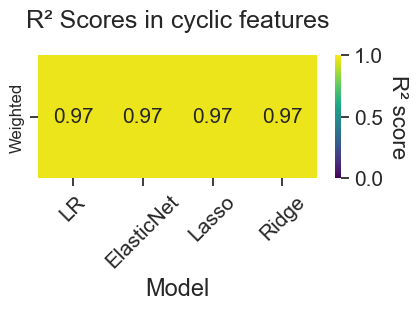

In [80]:
linear_results = {
    'LR': [0.97,],
    'ElasticNet': [0.97,],
    'Lasso': [.97,],
    'Ridge': [0.97,],
}
index = [ 'Weighted']
result_df = pd.DataFrame(linear_results, index=index)

_draw_heatmap_scores(result_df,figsize=(4.5,1.6),title='R² Scores in cyclic features')

### Spline periodic features

In [81]:
X_ordinal = dataset[[
    "location",
    # "electrode",
    # "carbon number",
    "temperature",
    "log_water content",
    "time of day",
    "day of week",
    # "day of year"
]]

In [82]:
spline_preprocess = ColumnTransformer(transformers=[
    ("continuous", RobustScaler(), [
        # "carbon number",
        "temperature",
        "log_water content",
    ]),
    ("time_day", Pipeline([
        # ("scale", time_scaler),
        ("spline", SplineTransformer(degree=3, extrapolation="periodic"))
    ]), ["time of day"]),
    ("day_week", Pipeline([
        # ("scale", week_scaler),
        ("spline", SplineTransformer(degree=3, extrapolation="periodic"))
    ]), ["day of week"]),
    ("categorical", OrdinalEncoder(categories=[['Boston, Massachusetts','Ames, Iowa']]), ["location"]),
    # ("categorical", OneHotEncoder(), ["location"]),
    ],verbose_feature_names_out=False)

spline_params = {
    "feature_scaling__time_day__spline__n_knots": Integer(4, 24, prior="log-uniform", base=2),
    "feature_scaling__day_week__spline__n_knots": Integer(4, 7),
  }

#### Lasso

*Weighted + residual score*

Weight applied


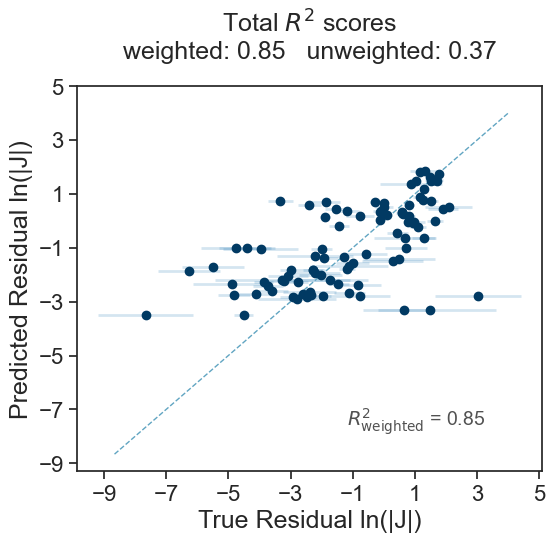

17
weighted_r2 0.85
adjusted_weighted_r2 0.81
unweighted_r2 0.37
adjusted_unweighted_r2 0.22
intercept: 0.00


In [83]:
transformed_regressor = TransformedTargetRegressor(
    regressor=LassoCV(alphas=[1e-4, 1e-2, 1e-1], fit_intercept=False),
    # regressor=LassoCV(),
    transformer=RobustScaler()
)

spline_lasso_pipeline = Pipeline([
    ("feature_scaling", spline_preprocess),
    ("model", transformed_regressor)
    # ("model", LassoCV())
  ])
lasso_spline_params = {
    **spline_params,
    # "model__l1_ratio": Real(1e-2, 1, prior="log-uniform"),
}


spline_lasso_hyperopt = make_bayes_opt(spline_lasso_pipeline, lasso_spline_params)

model = calculate_total_r2_score(spline_lasso_hyperopt, features=X_ordinal,heterosked_model=True, pure_residual_prediction=True)

regressor = model.best_estimator_.named_steps["model"].regressor_
print(f"intercept: {regressor.intercept_:0.2f}")

# for feat_name, coef in zip(model.best_estimator_.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_):
#   print(f"{feat_name}: {coef:0.2f}")

*Weighted + Combined Score*

Weight applied


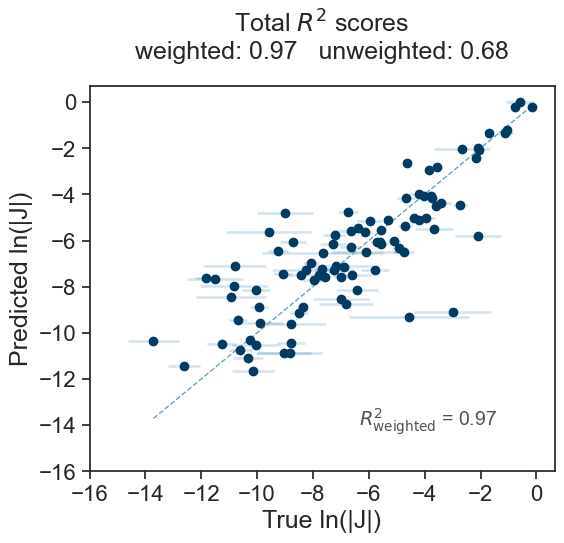

22
weighted_r2 0.97
adjusted_weighted_r2 0.96
unweighted_r2 0.68
adjusted_unweighted_r2 0.58
intercept: 0.00


In [84]:
transformed_regressor = TransformedTargetRegressor(
    regressor=LassoCV(alphas=[10e-6, 1e-4, 1e-2, 1e-1, 1, 10], fit_intercept=False),
    # regressor=LassoCV(),
    transformer=RobustScaler()
)

spline_lasso_pipeline = Pipeline([
    ("feature_scaling", spline_preprocess),
    ("model", transformed_regressor)
    # ("model", LassoCV())
  ])
lasso_spline_params = {
    **spline_params,
    # "model__l1_ratio": Real(1e-2, 1, prior="log-uniform"),
}


spline_lasso_hyperopt = make_bayes_opt(spline_lasso_pipeline, lasso_spline_params)

model = calculate_total_r2_score(spline_lasso_hyperopt, features=X_ordinal,heterosked_model=True)

regressor = model.best_estimator_.named_steps["model"].regressor_
print(f"intercept: {regressor.intercept_:0.2f}")

# for feat_name, coef in zip(model.best_estimator_.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_):
#   print(f"{feat_name}: {coef:0.2f}")

In [85]:
lasso_cv = model.best_estimator_.named_steps["model"].regressor_
print("Selected alpha:", lasso_cv.alpha_)


Selected alpha: 0.0001


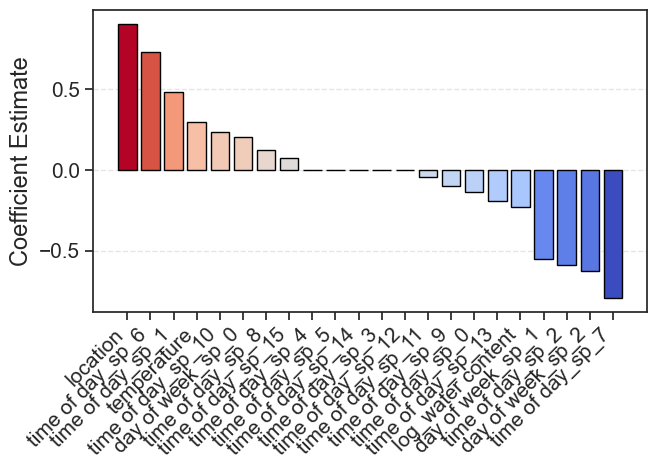

In [86]:
draw_feature_importance(model.best_estimator_.named_steps["feature_scaling"].get_feature_names_out(), regressor.coef_,figsize=(7,5),fontsize=17)

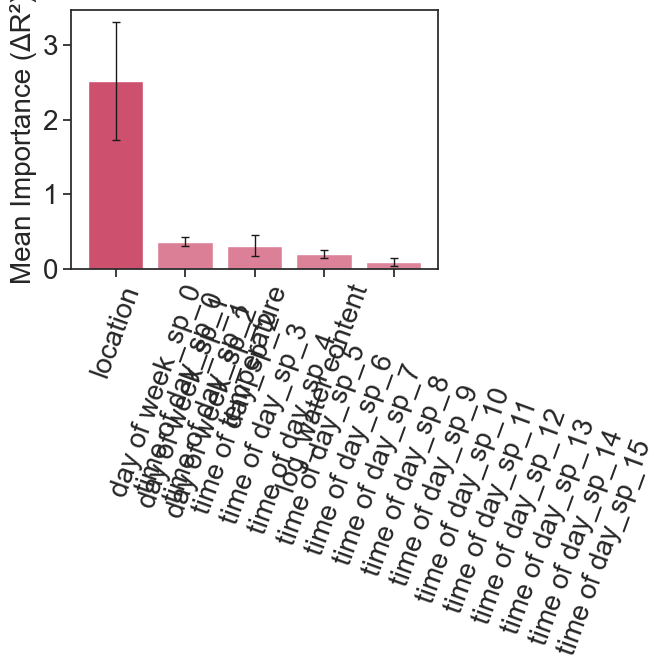

In [87]:
pipe = model.best_estimator_
pipe.set_output(transform="pandas")

X_trans = pipe[:-1].transform(X_ordinal)

import re

def build_groups(features):
    day_splines = [f for f in features if f.startswith("time of day_sp_")]
    week_splines = [f for f in features if f.startswith("day of week_sp_")]
    others = [f for f in features if f not in day_splines + week_splines]

    idxs = []
    if day_splines:
        idxs.append(day_splines)
    if week_splines:
        idxs.append(week_splines)
    for f in others:
        idxs.append([f])

    return idxs

feature_names = pipe.named_steps["feature_scaling"].get_feature_names_out(
    X_ordinal.columns
)
idxs = build_groups(feature_names)
draw_permute_feature_imp(pipe.named_steps["model"],
                         feat=X_trans,
                         target=y,sample_weight=y_weights,figsize=(7,7),idx=idxs,fontsize=20)

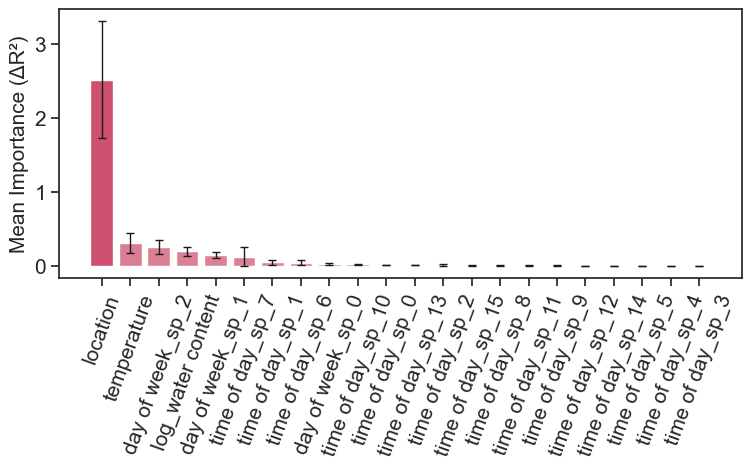

In [88]:
draw_permute_feature_imp(pipe.named_steps["model"],
                         feat=X_trans,
                         target=y,sample_weight=y_weights,figsize=(8,5),fontsize=15,idx=[[f] for f in feature_names] )

In [89]:
spline_feats = model.best_estimator_.named_steps["feature_scaling"].get_feature_names_out().tolist()
print(spline_feats)

['temperature', 'log_water content', 'time of day_sp_0', 'time of day_sp_1', 'time of day_sp_2', 'time of day_sp_3', 'time of day_sp_4', 'time of day_sp_5', 'time of day_sp_6', 'time of day_sp_7', 'time of day_sp_8', 'time of day_sp_9', 'time of day_sp_10', 'time of day_sp_11', 'time of day_sp_12', 'time of day_sp_13', 'time of day_sp_14', 'time of day_sp_15', 'day of week_sp_0', 'day of week_sp_1', 'day of week_sp_2', 'location']


**Partial Dependance**

In [90]:
common_params = {
    "subsample": .99,
    "n_jobs": -1,
    "grid_resolution": 20,
    "random_state": 42,
}

print("Computing partial dependence plots...")
features_info = {
    # features of interest
    "features": [
        *spline_feats
        ],
    # type of partial dependence plot
        "kind": "average",
    # "centered": True,

    # information regarding categorical features
    "categorical_features": ["location"],
}

Computing partial dependence plots...


In [91]:
spline_step = model.best_estimator_.named_steps["feature_scaling"]

X_spline = spline_step.transform(X_ordinal)
spline_feature_names = spline_step.get_feature_names_out()

X_spline = pd.DataFrame(
    X_spline,
    columns=spline_feature_names,
    index=X_ordinal.index
)

In [92]:
lasso = model.best_estimator_.named_steps["model"].regressor_

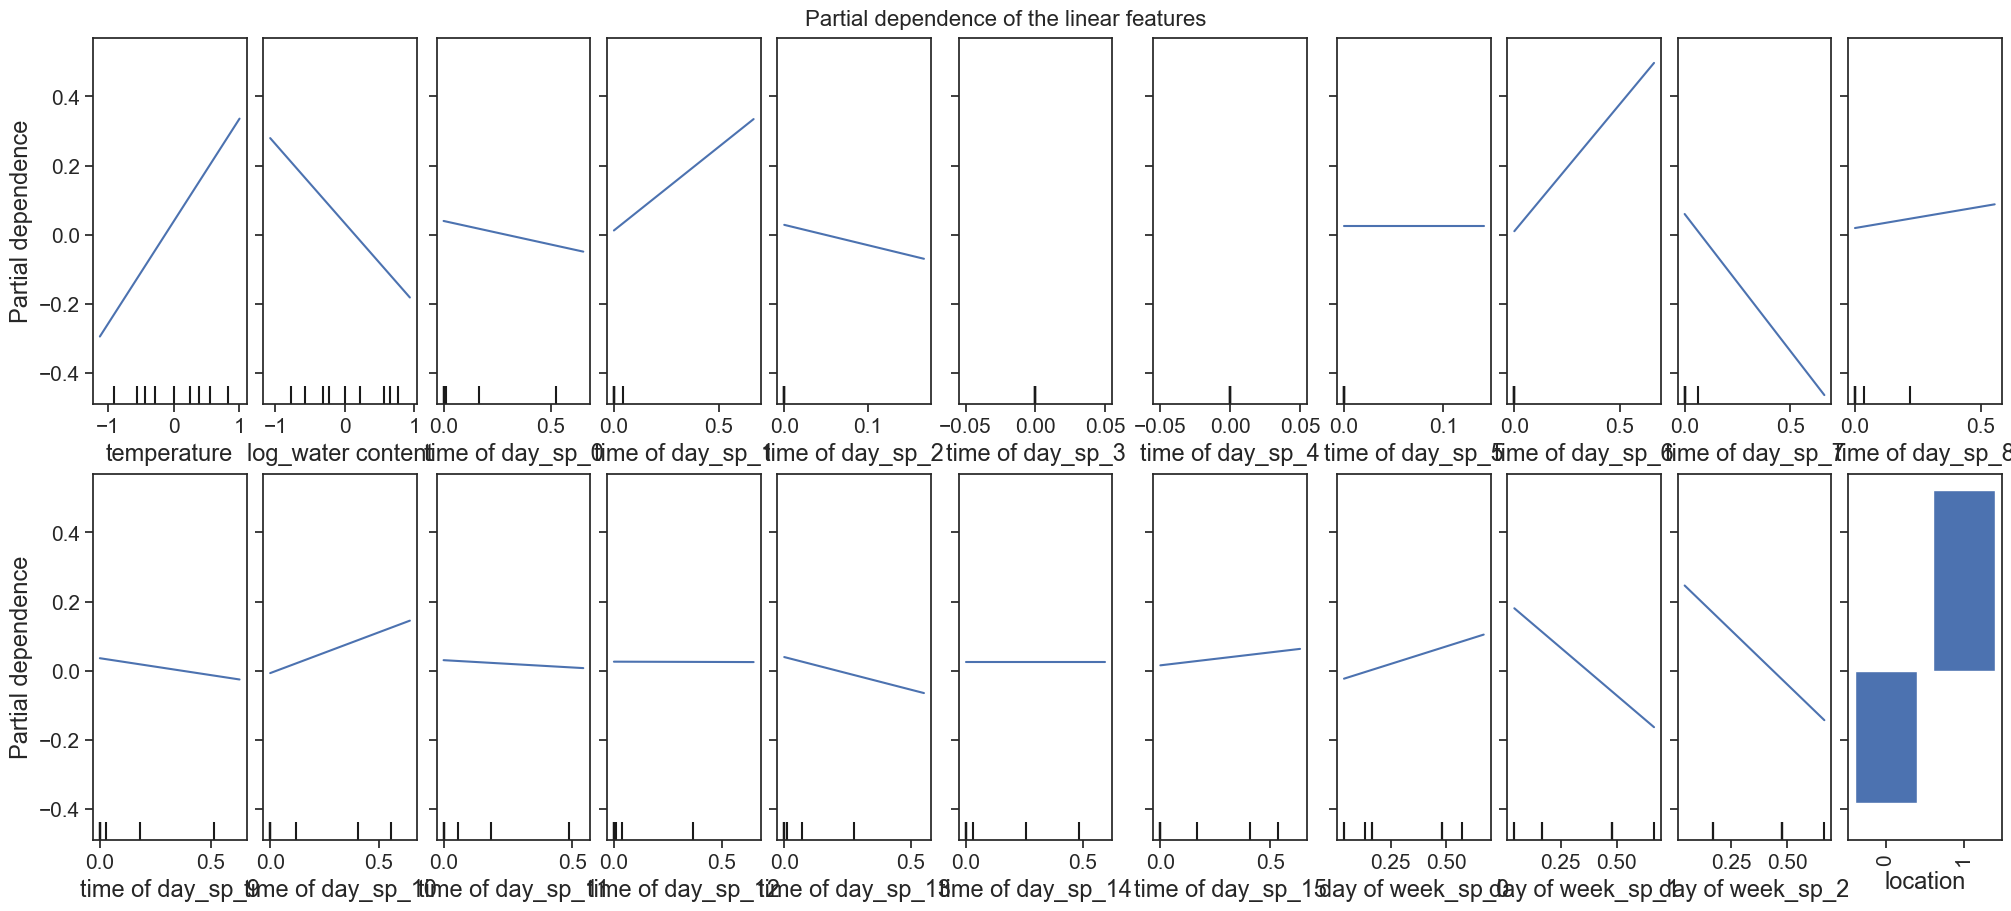

In [93]:
_, ax = plt.subplots(ncols=11, nrows=2, figsize=(20, 9), constrained_layout=True)
display = PartialDependenceDisplay.from_estimator(
    lasso,
    X_spline,
    **features_info,
    ax=ax,
    **common_params,
)
_ = display.figure_.suptitle(
    (
        "Partial dependence of the linear features"

    ),
    fontsize=16,
)

#### ElasticNet

*Weighted + combined score*

Weight applied


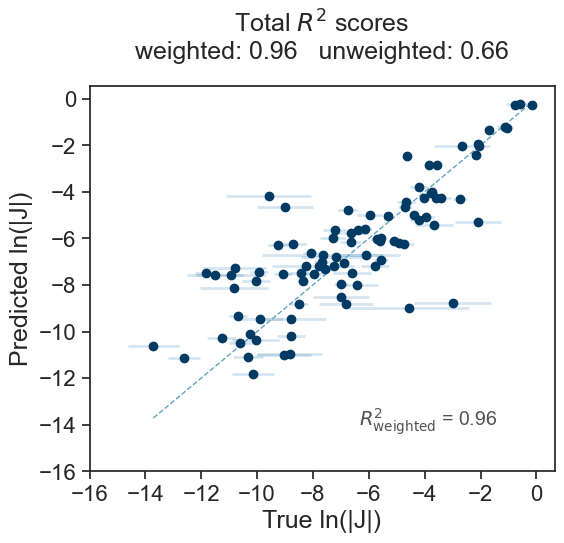

22
weighted_r2 0.96
adjusted_weighted_r2 0.95
unweighted_r2 0.66
adjusted_unweighted_r2 0.55


In [94]:
transformed_regressor = TransformedTargetRegressor(
    regressor=ElasticNetCV(l1_ratio=[1e-2, 1e-1, 0.5, 1e0], fit_intercept=False),
    transformer=RobustScaler()
)

spline_elasticnet_pipeline = Pipeline([
    ("feature_scaling", spline_preprocess),
    ("model", transformed_regressor)
  ])

spline_elasticnet_pipeline = Pipeline([
    ("feature_scaling", spline_preprocess),
    # ("model", ElasticNetCV(l1_ratio=[1e-2, 1e-1, 0.5, 1e0], fit_intercept=False))
    ("model", transformed_regressor)
  ])

elasticnet_spline_params = {
    **spline_params,
    # "model__l1_ratio": Real(1e-2, 1, prior="log-uniform"),
}

spline_elasticnet_hyperopt = make_bayes_opt(spline_elasticnet_pipeline, elasticnet_spline_params)

spline_elasticnet_model = calculate_total_r2_score(spline_elasticnet_hyperopt, features=X_ordinal, sample_weights=y_weights,heterosked_model=True)

<class 'sklearn.compose._column_transformer.ColumnTransformer'>
L1 ratio: 1.00	alpha: 0.00	intercept: 0.00


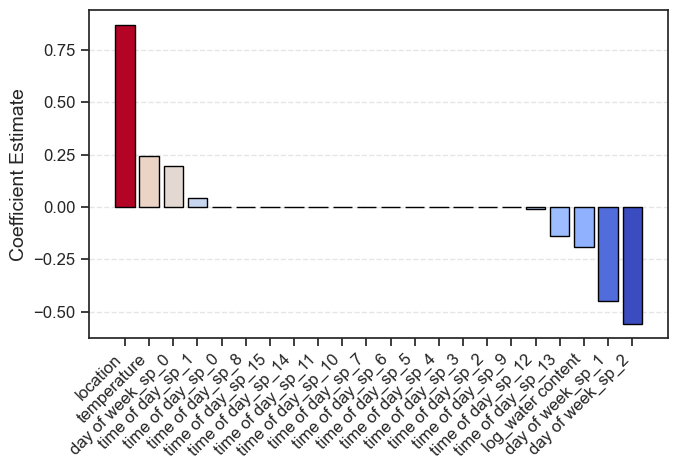

In [95]:
model = spline_elasticnet_model

regressor = model.best_estimator_.named_steps["model"].regressor_
features = model.best_estimator_.named_steps["feature_scaling"]
print(type(features))

print(f"L1 ratio: {regressor.l1_ratio_:0.2f}\talpha: {regressor.alpha_:0.2f}\tintercept: {regressor.intercept_:0.2f}")

# for feat_name, coef in zip(features.get_feature_names_out(), regressor.coef_):
#   print(f"{feat_name}: {coef:0.2f}")


draw_feature_importance(features.get_feature_names_out(), regressor.coef_,figsize=(7,5),fontsize=14)

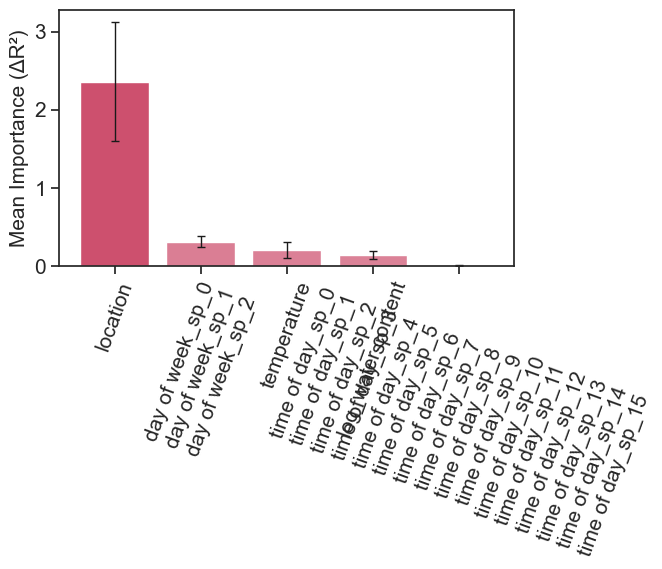

In [96]:
pipe = model.best_estimator_
pipe.set_output(transform="pandas")

X_trans = pipe[:-1].transform(X_ordinal)


def build_groups(features):
    day_splines = [f for f in features if f.startswith("time of day_sp_")]
    week_splines = [f for f in features if f.startswith("day of week_sp_")]
    others = [f for f in features if f not in day_splines + week_splines]

    idxs = []
    if day_splines:
        idxs.append(day_splines)
    if week_splines:
        idxs.append(week_splines)
    for f in others:
        idxs.append([f])

    return idxs

feature_names = pipe.named_steps["feature_scaling"].get_feature_names_out(
    X_ordinal.columns
)
idxs = build_groups(feature_names)
draw_permute_feature_imp(pipe.named_steps["model"],
                         feat=X_trans,
                         target=y,sample_weight=y_weights,figsize=(7,6),idx=idxs,fontsize=15)

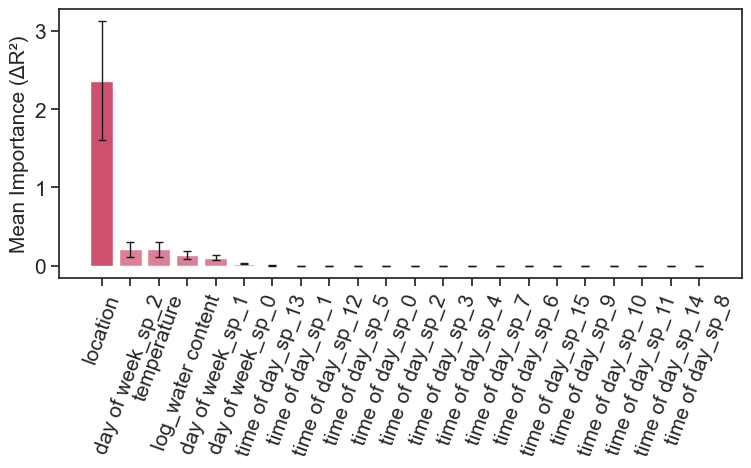

In [97]:
draw_permute_feature_imp(pipe.named_steps["model"],
                         feat=X_trans,
                         target=y,sample_weight=y_weights,figsize=(8,5),fontsize=15,idx=[[f] for f in feature_names] )

#### Ridge

*Weighted*

Weight applied


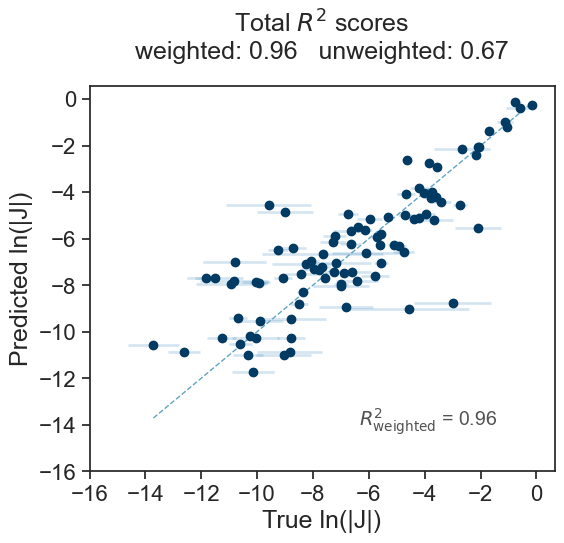

16
weighted_r2 0.96
adjusted_weighted_r2 0.96
unweighted_r2 0.67
adjusted_unweighted_r2 0.6
<class 'sklearn.compose._column_transformer.ColumnTransformer'>
intercept: 0.00


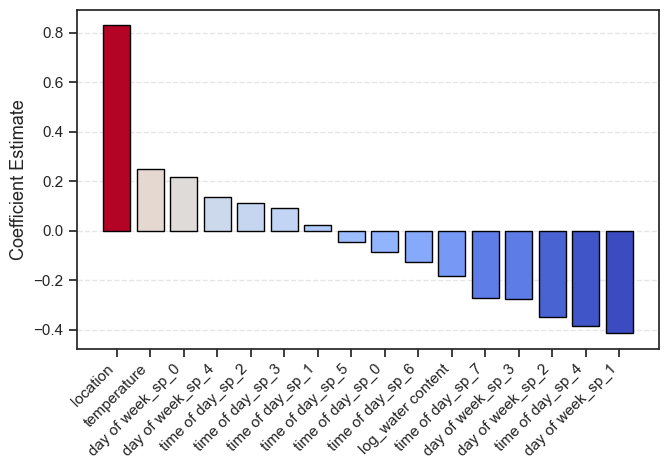

In [98]:
transformed_regressor = TransformedTargetRegressor(
    regressor=RidgeCV(alphas=[1e-4, 1e-2, 1e-1, 0.5, 1e0, 1e1, 1e2, 1e3], fit_intercept=False),
    transformer=RobustScaler()
)

spline_lasso_pipeline = Pipeline([
    ("feature_scaling", spline_preprocess),
    ("model", transformed_regressor)
  ])

spline_lasso_pipeline = Pipeline([
    ("feature_scaling", spline_preprocess),
    ("model", transformed_regressor)
  ])

lasso_spline_params = {
    **spline_params,
    # "model__l1_ratio": Real(1e-2, 1, prior="log-uniform"),
}

spline_lasso_hyperopt = make_bayes_opt(spline_lasso_pipeline, lasso_spline_params)
spline_lasso_model = calculate_total_r2_score(spline_lasso_hyperopt, features=X_ordinal, sample_weights=y_weights,heterosked_model=True)

model = spline_lasso_model

regressor = model.best_estimator_.named_steps["model"].regressor_
features = model.best_estimator_.named_steps["feature_scaling"]
print(type(features))

print(f"intercept: {regressor.intercept_:0.2f}")

# for feat_name, coef in zip(features.get_feature_names_out(), regressor.coef_):
#   print(f"{feat_name}: {coef:0.2f}")


draw_feature_importance(features.get_feature_names_out(), regressor.coef_,figsize=(7,5),fontsize=13)

In [99]:
ridge_cv = model.best_estimator_.named_steps["model"].regressor_
print("Selected alpha:", ridge_cv.alpha_)


Selected alpha: 10.0


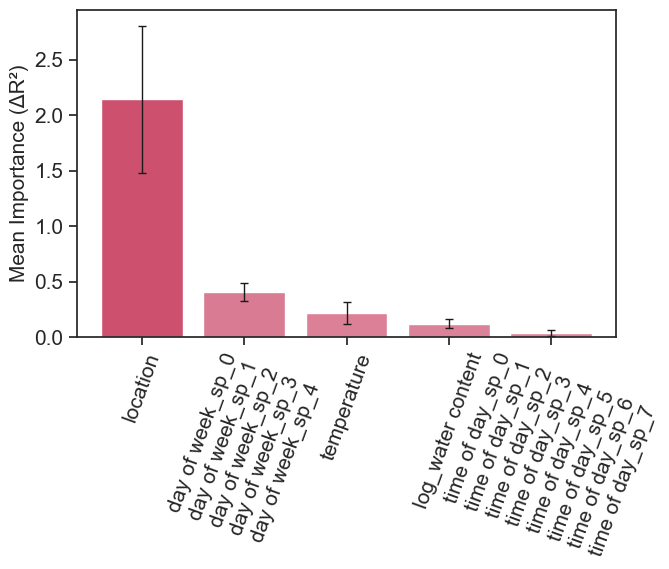

In [100]:
pipe = model.best_estimator_
pipe.set_output(transform="pandas")

X_trans = pipe[:-1].transform(X_ordinal)


feature_names = pipe.named_steps["feature_scaling"].get_feature_names_out(
    X_ordinal.columns
)
idxs = build_groups(feature_names)
draw_permute_feature_imp(pipe.named_steps["model"],
                         feat=X_trans,
                         target=y,sample_weight=y_weights,figsize=(7,6),idx=idxs,fontsize=15)

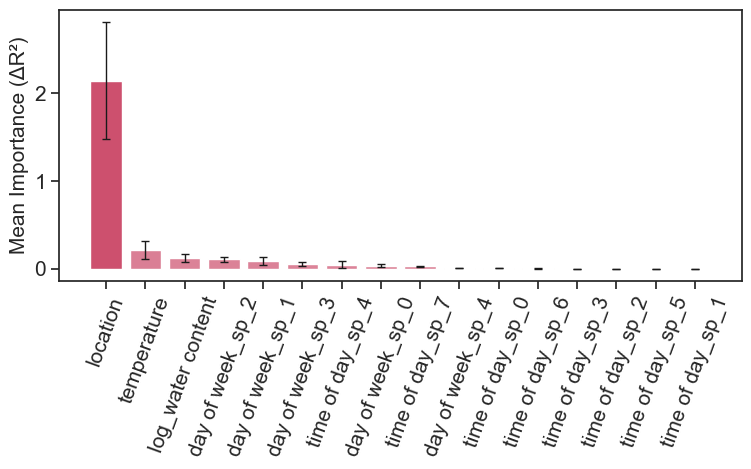

In [101]:
draw_permute_feature_imp(pipe.named_steps["model"],
                         feat=X_trans,
                         target=y,sample_weight=y_weights,figsize=(8,5),fontsize=15,idx=[[f] for f in feature_names] )

#### Weighted Linear Regression

*Weighted + residual Score*

Weight applied


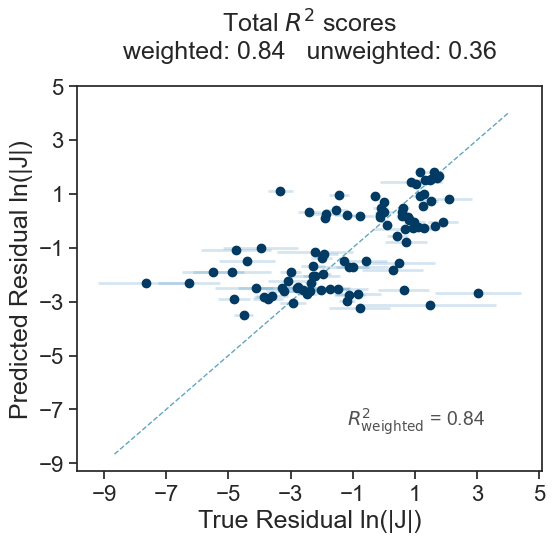

12
weighted_r2 0.84
adjusted_weighted_r2 0.81
unweighted_r2 0.36
adjusted_unweighted_r2 0.26


In [102]:
transformed_regressor = TransformedTargetRegressor(
    regressor=LinearRegression(),
    transformer=RobustScaler()
)

spline_wls_pipeline = Pipeline([
    ("feature_scaling", spline_preprocess),
    ("model", transformed_regressor)
  ])

wls_bayes_model = calculate_total_r2_score(make_bayes_opt(spline_wls_pipeline, spline_params), features=X_ordinal, heterosked_model=True, pure_residual_prediction=True)

*Weighted + Combined Score*

Weight applied


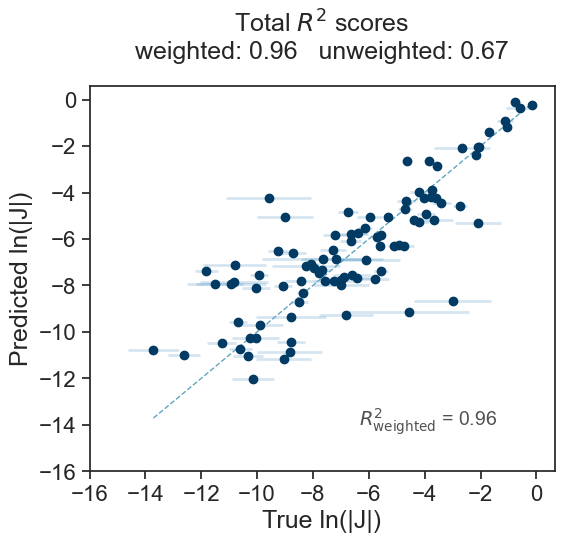

12
weighted_r2 0.96
adjusted_weighted_r2 0.96
unweighted_r2 0.67
adjusted_unweighted_r2 0.62


In [103]:
transformed_regressor = TransformedTargetRegressor(
    regressor=LinearRegression(),
    transformer=RobustScaler()
)

spline_wls_pipeline = Pipeline([
    ("feature_scaling", spline_preprocess),
    ("model", transformed_regressor)
  ])

wls_bayes_model = calculate_total_r2_score(make_bayes_opt(spline_wls_pipeline, spline_params), features=X_ordinal, heterosked_model=True)

<class 'sklearn.compose._column_transformer.ColumnTransformer'>
intercept: -0.31


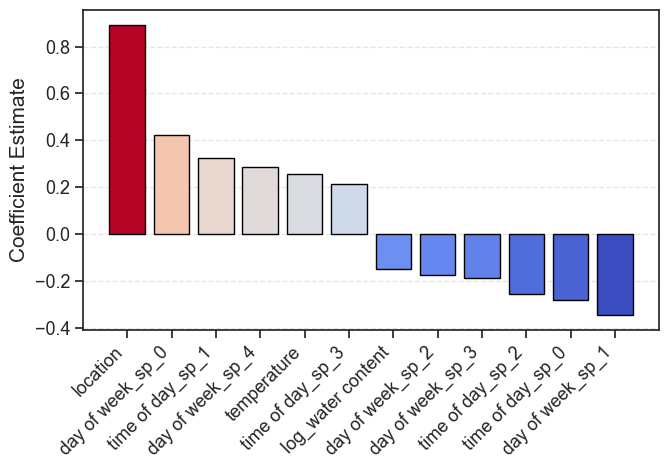

In [104]:
model = wls_bayes_model

regressor = model.best_estimator_.named_steps["model"].regressor_
features = model.best_estimator_.named_steps["feature_scaling"]
print(type(features))
print(f"intercept: {regressor.intercept_:0.2f}")


# for feat_name, coef in zip(features.get_feature_names_out(), regressor.coef_):
#   print(f"{feat_name}: {coef:0.2f}")

draw_feature_importance(features.get_feature_names_out(), regressor.coef_,figsize=(7,5),fontsize=15)

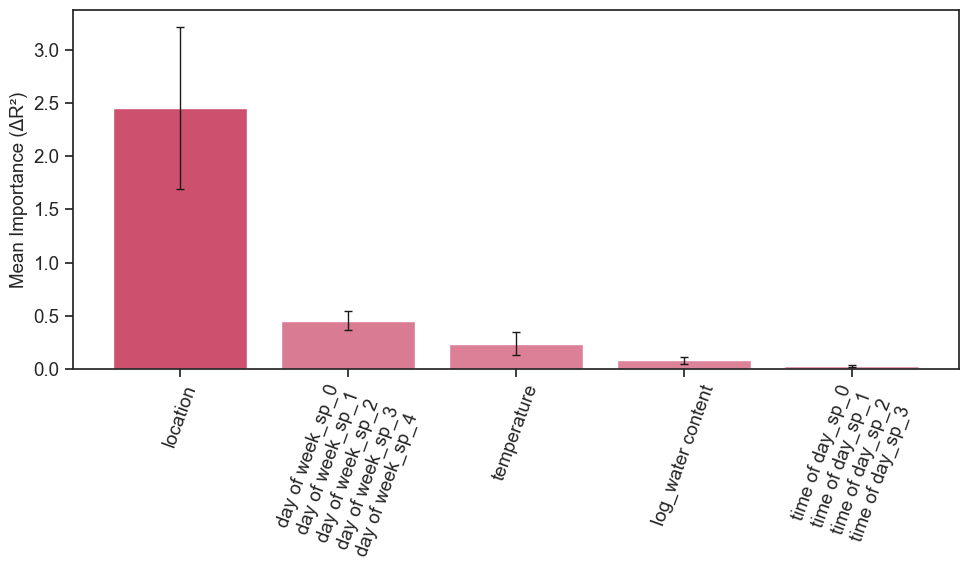

In [105]:
pipe = model.best_estimator_
pipe.set_output(transform="pandas")

X_trans = pipe[:-1].transform(X_ordinal)

import re

def build_groups(features):
    day_splines = [f for f in features if f.startswith("time of day_sp_")]
    week_splines = [f for f in features if f.startswith("day of week_sp_")]
    others = [f for f in features if f not in day_splines + week_splines]

    idxs = []
    if day_splines:
        idxs.append(day_splines)
    if week_splines:
        idxs.append(week_splines)
    for f in others:
        idxs.append([f])

    return idxs

feature_names = pipe.named_steps["feature_scaling"].get_feature_names_out(
    X_ordinal.columns
)
idxs = build_groups(feature_names)
draw_permute_feature_imp(pipe.named_steps["model"],
                         feat=X_trans,
                         target=y,sample_weight=y_weights,figsize=(10,6),idx=idxs,fontsize=13.5)

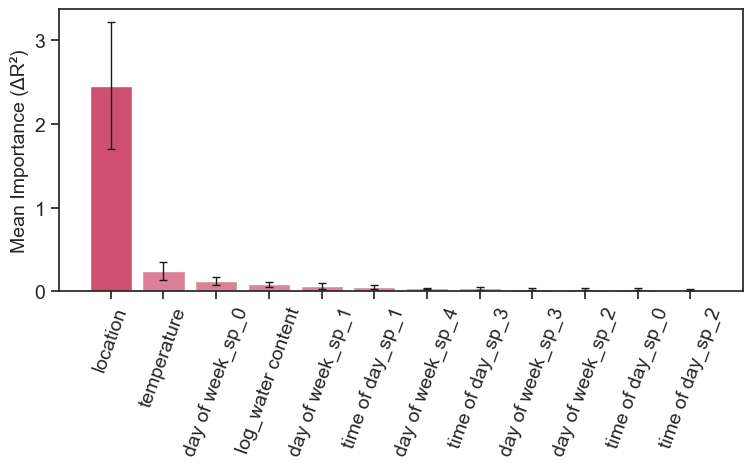

In [106]:
draw_permute_feature_imp(pipe.named_steps["model"],
                         feat=X_trans,
                         target=y,sample_weight=y_weights,figsize=(8,5),fontsize=14,idx=[[f] for f in feature_names] )

### Aggregated results

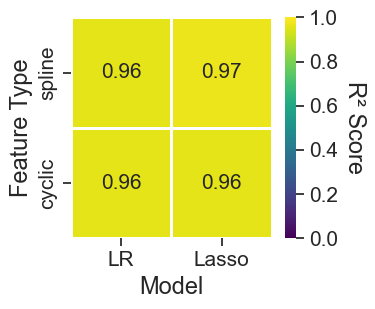

In [107]:
# ---- Data ----
periodic_results = {
    'LR': [0.96, 0.96],
    'Lasso': [0.97, 0.96],
}

index = ['spline', 'cyclic']
result_df = pd.DataFrame(periodic_results, index=index)


# ---- Heatmap Function ----
def _draw_heatmap_scores(df, figsize=(4.5, 4), title=None):
    plt.figure(figsize=figsize)

    ax = sns.heatmap(
        df,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        vmin=0,
        vmax=1,
        linewidths=0.8,
        cbar_kws={"label": "R² Score"},
        annot_kws={"size": 15}
    )
    cbar = ax.collections[0].colorbar
    cbar.set_label("R² Score", rotation=270, labelpad=20, fontsize=17)
    ax.set_xlabel("Model", fontsize=17)
    ax.set_ylabel("Feature Type", fontsize=17)
    ax.tick_params(axis='both', labelsize=15)

    if title:
        ax.set_title(title, fontsize=15, pad=10)

    plt.tight_layout()
    plt.show()


# ---- Draw ----
_draw_heatmap_scores(
    result_df,
    figsize=(4, 3.4),
    # title='R² Scores in periodic features'
)